# Distribuição de Frequência de Dados | Gráficos

**Pontifícia Universidade Católica do Paraná**

**Ciência da Computação**

**Disciplina:** Métodos Quantitativos (PUCPR)  
## **Aluno:** Jafte Carneiro Fagundes da Silva  
**Base:** Wine Quality (UCI Machine Learning Repository — id=186)  
**Variações:** red + white (dataset combinado)  
**Objetivo:** construir tabelas de distribuição de frequência com intervalos de classe, para cada variável, e gerar visualizações.

## Decisões metodológicas do aluno
1. Além de **frequência absoluta (fi)** e **acumulada (Fi)**, também serão calculadas **frequência relativa (fr)** e **relativa acumulada (Fr)**, por serem boas práticas para interpretação e comparação.
2. A geração das tabelas será **automatizada para todas as variáveis numéricas**, para garantir reprodutibilidade.
3. Para os gráficos principais será utilizada a variável **alcohol**, por sua relevância no paper de Cortez et al. (2009).

## Referências
- UCI ML Repository — Wine Quality (id=186): https://archive.ics.uci.edu/dataset/186/wine+quality  
- Cortez, P. et al. (2009). *Modeling wine preferences by data mining from physicochemical properties*. Decision Support Systems, 47, 547–553.
  Link: https://www.semanticscholar.org/paper/Modeling-wine-preferences-by-data-mining-from-Cortez-Cerdeira/bf15a0ccc14ac1deb5cea570c870389c16be019c

# 1. Caracterização do Tipo de Dado e do Problema

### Continuação do Trabalho A09

---

# 2. Quantidade de Atributos e Classificação dos Tipos

A base combinada (vinhos tintos e brancos) possui **13 atributos**, considerando a coluna indicadora do tipo de vinho adicionada na combinação `concat` dos datasets.

As variáveis são classificadas da seguinte forma:

### Variáveis físico-químicas (11 variáveis — contínuas)

1. fixed acidity — contínua
2. volatile acidity — contínua
3. citric acid — contínua
4. residual sugar — contínua
5. chlorides — contínua
6. free sulfur dioxide — contínua
7. total sulfur dioxide — contínua
8. density — contínua
9. pH — contínua
10. sulphates — contínua
11. alcohol — contínua

Essas variáveis representam medições laboratoriais em escala real, sendo tratadas como variáveis quantitativas contínuas.

### Variável de saída

12. quality — **ordinal discreta**

A variável qualidade assume valores inteiros em escala ordenada (por exemplo, 3 a 9), representando avaliação sensorial.

### Variável categórica adicionada na combinação

13. wine_type — **nominal**

Indica se a observação refere-se a vinho tinto (*red*) ou branco (*white*), não havendo ordenação entre as categorias.

---



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Instalação de Dependências

In [2]:
!pip -q install ucimlrepo pandas numpy matplotlib seaborn

# Importação e utilidades

In [3]:
import os
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from ucimlrepo import fetch_ucirepo

os.makedirs("export", exist_ok=True)
os.makedirs("export/freq_tables", exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

# Carregamento: `fetch_ucirepo` + fallback UCI

In [4]:
def load_wine_quality_combined(dataset_id: int = 186) -> pd.DataFrame:
    """
    Carrega Wine Quality (UCI id=186) e retorna o dataset combinado (red + white)
    com a coluna 'wine_type'.

    Regra:
    - Primeiro tenta executar fetch_ucirepo (para cumprir o requisito do exercício).
    - Independentemente do formato retornado, usa o download oficial do UCI para
      garantir o combinado red+white com coluna wine_type.
    """
    used_ucimlrepo = False
    try:
        _ = fetch_ucirepo(id=dataset_id)  # apenas para cumprir o requisito
        used_ucimlrepo = True
    except Exception as e:
        print(f"[Aviso] fetch_ucirepo falhou (id={dataset_id}). Motivo: {type(e).__name__}: {e}")

    # Download oficial do UCI (garante combinado)
    url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

    red = pd.read_csv(url_red, sep=";")
    red["wine_type"] = "red"

    white = pd.read_csv(url_white, sep=";")
    white["wine_type"] = "white"

    df = pd.concat([red, white], ignore_index=True)

    if used_ucimlrepo:
        print("[OK] fetch_ucirepo foi executado; dataset combinado gerado via download oficial do UCI (red + white).")
    else:
        print("[OK] Dataset combinado gerado via download oficial do UCI (red + white).")

    print("Shape:", df.shape)
    return df

df = load_wine_quality_combined()
df.head()

[OK] fetch_ucirepo foi executado; dataset combinado gerado via download oficial do UCI (red + white).
Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


# Carregamento da base de dados

In [5]:
# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

# unir features e target em um único DataFrame
df = pd.concat([X, y], axis=1)

print("Dimensões da base:", df.shape)
display(df.head())

print("\nMetadados:")
print(wine_quality.metadata)

print("\nInformações das variáveis:")
display(wine_quality.variables)

Dimensões da base: (6497, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Metadados:
{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine

,name,role,type,demographic,description,units,missing_values
0,fixed_acidity,Feature,Continuous,None,None,None,no
1,volatile_acidity,Feature,Continuous,None,None,None,no
2,citric_acid,Feature,Continuous,None,None,None,no
3,residual_sugar,Feature,Continuous,None,None,None,no
4,chlorides,Feature,Continuous,None,None,None,no
5,free_sulfur_dioxide,Feature,Continuous,None,None,None,no
6,total_sulfur_dioxide,Feature,Continuous,None,None,None,no
7,density,Feature,Continuous,None,None,None,no
8,pH,Feature,Continuous,None,None,None,no
9,sulphates,Feature,Continuous,None,None,None,no


# Inspeção inicial

In [6]:
print("Tipos de dados:")
display(df.dtypes)

print("\nValores ausentes por coluna:")
display(df.isnull().sum())

print("\nResumo estatístico:")
display(df.describe())

Tipos de dados:


,0
fixed_acidity,float64
volatile_acidity,float64
citric_acid,float64
residual_sugar,float64
chlorides,float64
free_sulfur_dioxide,float64
total_sulfur_dioxide,float64
density,float64
pH,float64
sulphates,float64



Valores ausentes por coluna:


,0
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
pH,0
sulphates,0



Resumo estatístico:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


# Lista das variáveis

In [7]:
variaveis = df.columns.tolist()
print("Variáveis da base:")
for v in variaveis:
    print("-", v)

Variáveis da base:
- fixed_acidity
- volatile_acidity
- citric_acid
- residual_sugar
- chlorides
- free_sulfur_dioxide
- total_sulfur_dioxide
- density
- pH
- sulphates
- alcohol
- quality


# Salvamento do data set original

In [8]:
original_path = "export/wine_quality_original.csv"
df.to_csv(original_path, index=False)
original_path

'export/wine_quality_original.csv'

# Exploração inicial
- Identificar tipos de variáveis (numéricas e categóricas)
- Verificar ausências

In [9]:
print("Valores ausentes por coluna:")
display(df.isna().sum())

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("Colunas numéricas:", num_cols)
print("Colunas não numéricas:", cat_cols)

display(df.describe().T)

Valores ausentes por coluna:


,0
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
pH,0
sulphates,0


Colunas numéricas: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Colunas não numéricas: []


,count,mean,std,min,25%,50%,75%,max
fixed_acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile_acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric_acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual_sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free_sulfur_dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total_sulfur_dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


## Classificação das variáveis (nominal, ordinal, discreta, contínua)

Critérios adotados:
- Variáveis físico-químicas (medidas) → **contínuas**
- `quality` → **ordinal e discreta** (nota inteira)
- `wine_type` → **nominal**

In [10]:
def classify_variable(series: pd.Series) -> str:
    if series.name == "wine_type":
        return "Nominal"
    if series.name == "quality":
        return "Ordinal (discreta)"
    if pd.api.types.is_integer_dtype(series):
        return "Discreta"
    if pd.api.types.is_float_dtype(series):
        return "Contínua"
    return "Nominal/Texto"

var_table = pd.DataFrame({
    "variavel": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "classificacao": [classify_variable(df[c]) for c in df.columns],
    "n_unicos": [df[c].nunique(dropna=True) for c in df.columns],
    "n_nulos": [df[c].isna().sum() for c in df.columns],
})
display(var_table)

,variavel,dtype,classificacao,n_unicos,n_nulos
0,fixed_acidity,float64,Contínua,106,0
1,volatile_acidity,float64,Contínua,187,0
2,citric_acid,float64,Contínua,89,0
3,residual_sugar,float64,Contínua,316,0
4,chlorides,float64,Contínua,214,0
5,free_sulfur_dioxide,float64,Contínua,135,0
6,total_sulfur_dioxide,float64,Contínua,276,0
7,density,float64,Contínua,998,0
8,pH,float64,Contínua,108,0
9,sulphates,float64,Contínua,111,0


# Função auxiliar para criar classes de frequência

In [11]:
print("Tamanho da amostra (n):", len(df))

Tamanho da amostra (n): 6497


In [12]:
def criar_classes_serie(serie, bins=5):
    serie = pd.to_numeric(serie, errors="coerce").dropna()

    if serie.empty:
        return pd.Series(dtype="int64")

    classes = pd.cut(serie, bins=bins, include_lowest=True)
    freq = classes.value_counts().sort_index()
    return freq

# Gráfico de linha

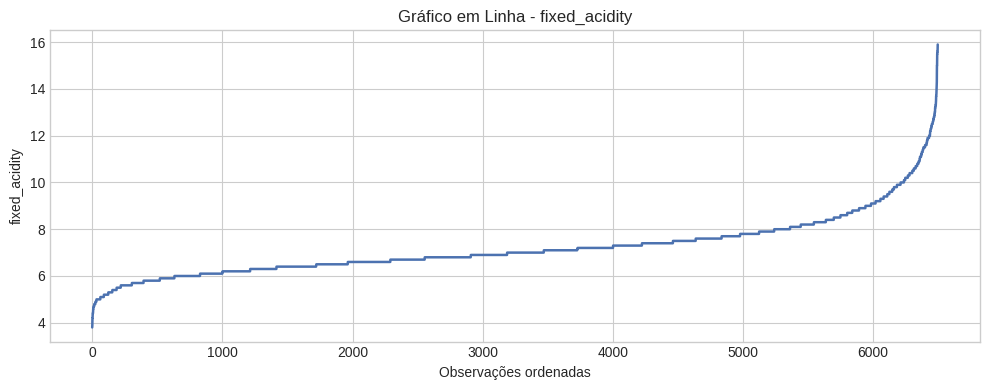

Comentário sobre fixed_acidity:
- O gráfico em linha de 'fixed_acidity' mostra a progressão dos valores em ordem crescente.
- Isso permite perceber a amplitude da variável, a concentração em certos intervalos e a presença de possíveis valores extremos.
- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; se houver saltos bruscos, isso pode indicar assimetria ou outliers.



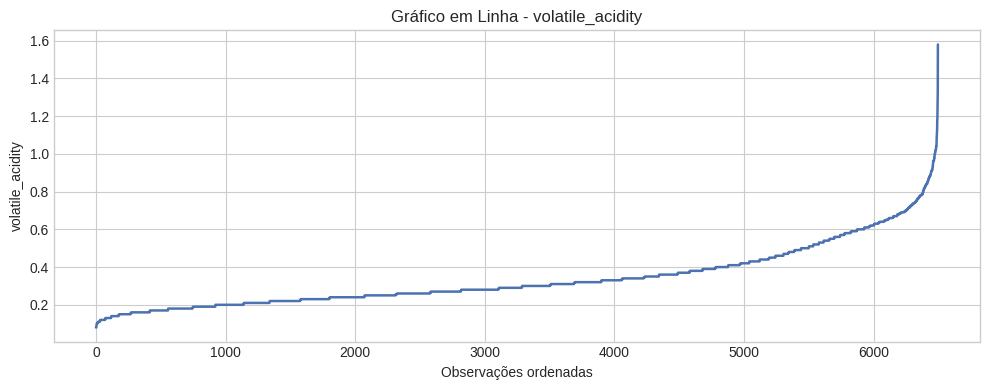

Comentário sobre volatile_acidity:
- O gráfico em linha de 'volatile_acidity' mostra a progressão dos valores em ordem crescente.
- Isso permite perceber a amplitude da variável, a concentração em certos intervalos e a presença de possíveis valores extremos.
- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; se houver saltos bruscos, isso pode indicar assimetria ou outliers.



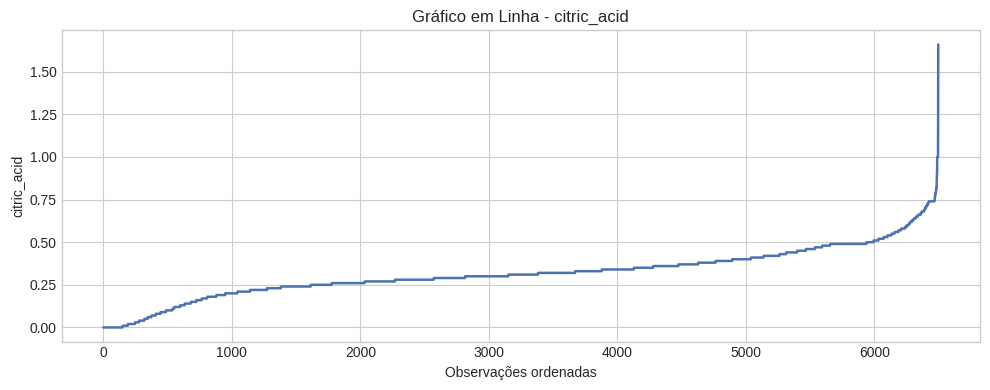

Comentário sobre citric_acid:
- O gráfico em linha de 'citric_acid' mostra a progressão dos valores em ordem crescente.
- Isso permite perceber a amplitude da variável, a concentração em certos intervalos e a presença de possíveis valores extremos.
- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; se houver saltos bruscos, isso pode indicar assimetria ou outliers.



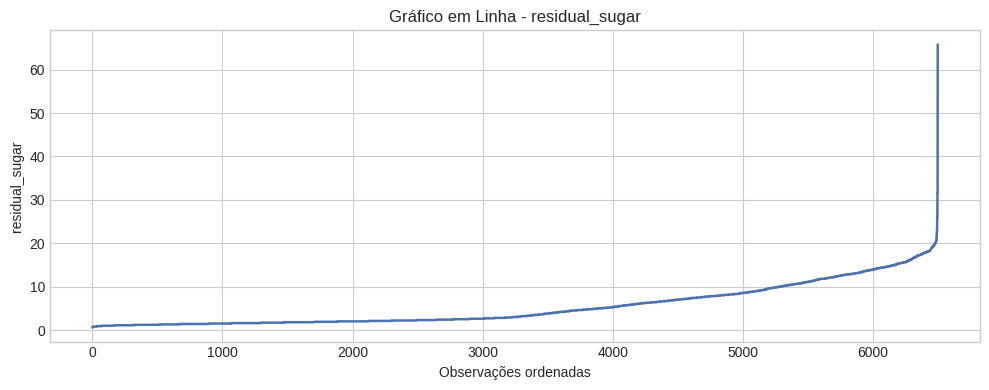

Comentário sobre residual_sugar:
- O gráfico em linha de 'residual_sugar' mostra a progressão dos valores em ordem crescente.
- Isso permite perceber a amplitude da variável, a concentração em certos intervalos e a presença de possíveis valores extremos.
- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; se houver saltos bruscos, isso pode indicar assimetria ou outliers.



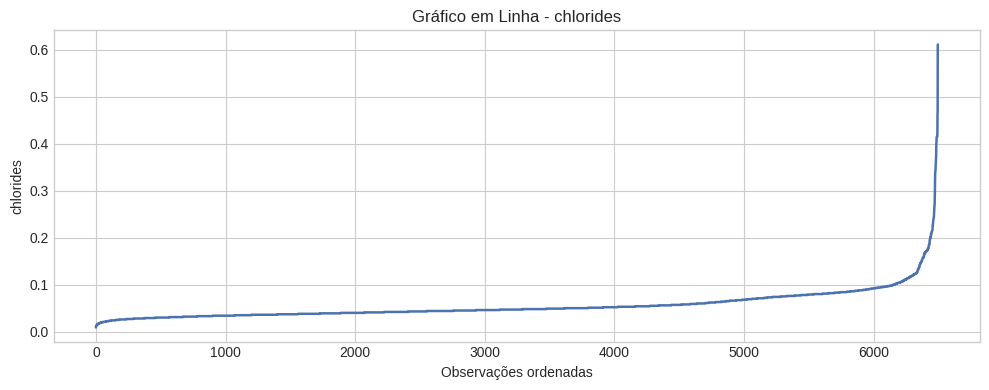

Comentário sobre chlorides:
- O gráfico em linha de 'chlorides' mostra a progressão dos valores em ordem crescente.
- Isso permite perceber a amplitude da variável, a concentração em certos intervalos e a presença de possíveis valores extremos.
- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; se houver saltos bruscos, isso pode indicar assimetria ou outliers.



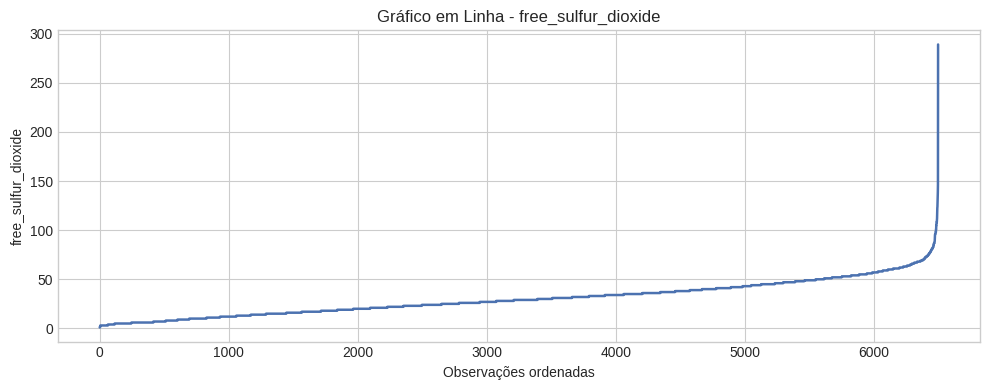

Comentário sobre free_sulfur_dioxide:
- O gráfico em linha de 'free_sulfur_dioxide' mostra a progressão dos valores em ordem crescente.
- Isso permite perceber a amplitude da variável, a concentração em certos intervalos e a presença de possíveis valores extremos.
- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; se houver saltos bruscos, isso pode indicar assimetria ou outliers.



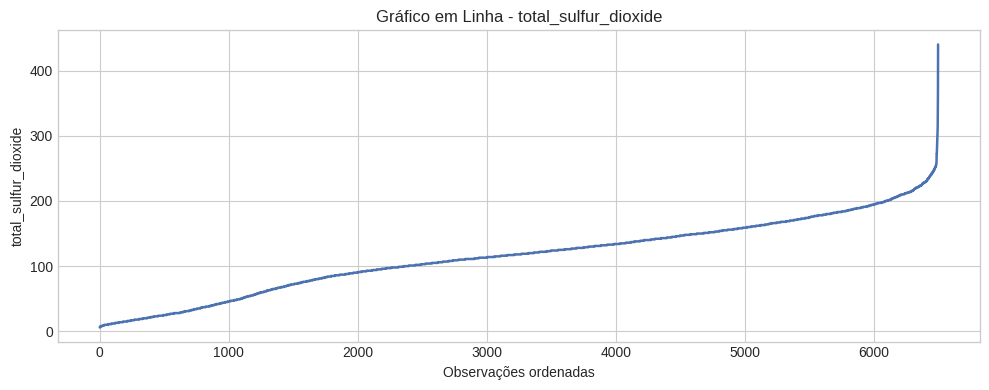

Comentário sobre total_sulfur_dioxide:
- O gráfico em linha de 'total_sulfur_dioxide' mostra a progressão dos valores em ordem crescente.
- Isso permite perceber a amplitude da variável, a concentração em certos intervalos e a presença de possíveis valores extremos.
- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; se houver saltos bruscos, isso pode indicar assimetria ou outliers.



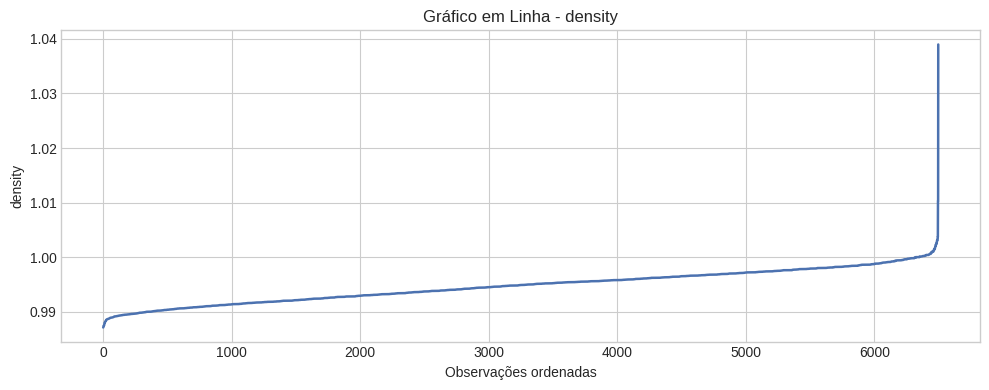

Comentário sobre density:
- O gráfico em linha de 'density' mostra a progressão dos valores em ordem crescente.
- Isso permite perceber a amplitude da variável, a concentração em certos intervalos e a presença de possíveis valores extremos.
- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; se houver saltos bruscos, isso pode indicar assimetria ou outliers.



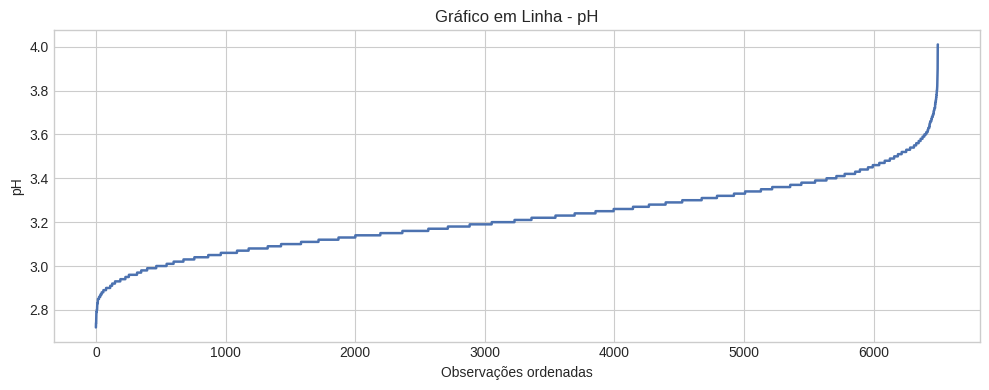

Comentário sobre pH:
- O gráfico em linha de 'pH' mostra a progressão dos valores em ordem crescente.
- Isso permite perceber a amplitude da variável, a concentração em certos intervalos e a presença de possíveis valores extremos.
- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; se houver saltos bruscos, isso pode indicar assimetria ou outliers.



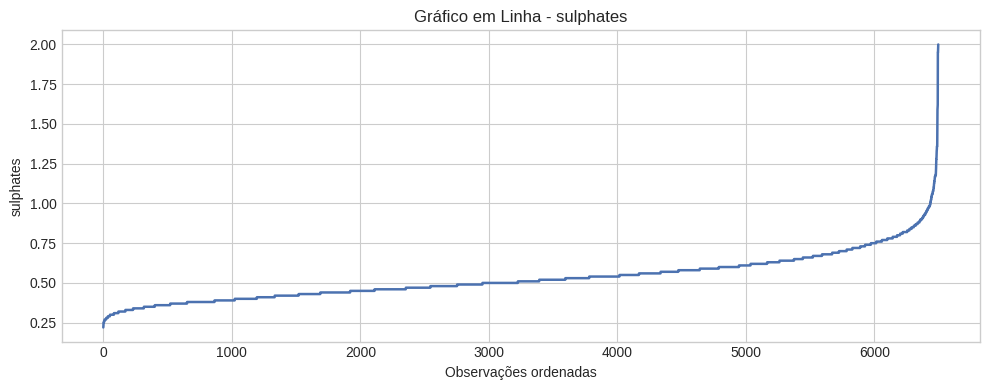

Comentário sobre sulphates:
- O gráfico em linha de 'sulphates' mostra a progressão dos valores em ordem crescente.
- Isso permite perceber a amplitude da variável, a concentração em certos intervalos e a presença de possíveis valores extremos.
- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; se houver saltos bruscos, isso pode indicar assimetria ou outliers.



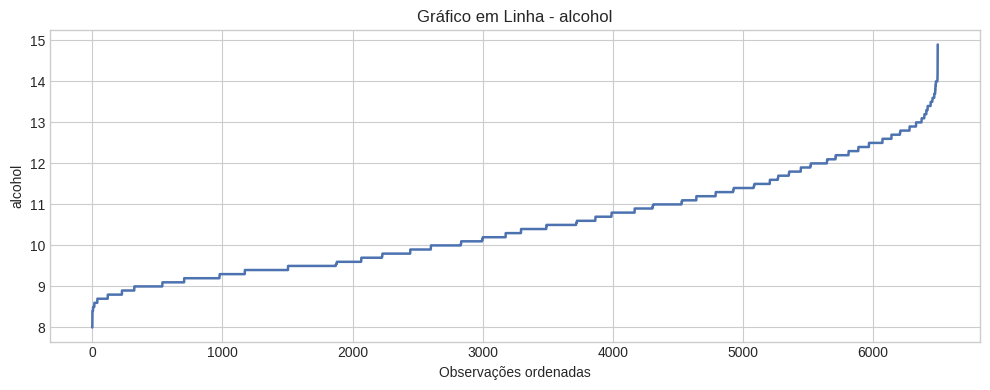

Comentário sobre alcohol:
- O gráfico em linha de 'alcohol' mostra a progressão dos valores em ordem crescente.
- Isso permite perceber a amplitude da variável, a concentração em certos intervalos e a presença de possíveis valores extremos.
- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; se houver saltos bruscos, isso pode indicar assimetria ou outliers.



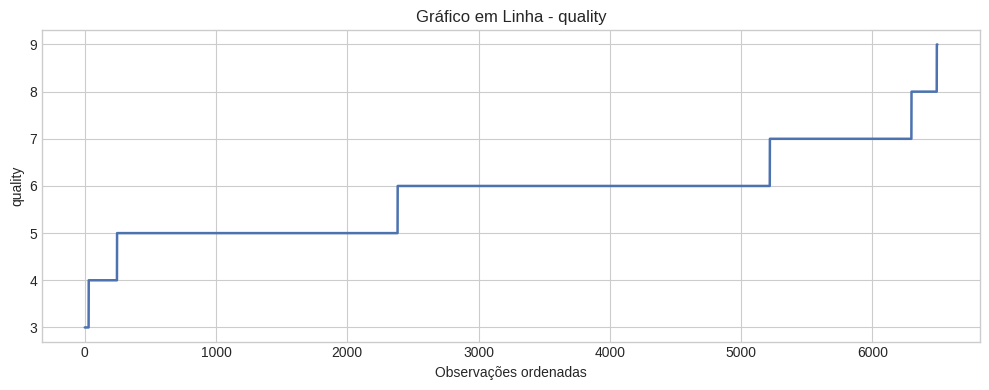

Comentário sobre quality:
- O gráfico em linha de 'quality' mostra a progressão dos valores em ordem crescente.
- Isso permite perceber a amplitude da variável, a concentração em certos intervalos e a presença de possíveis valores extremos.
- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; se houver saltos bruscos, isso pode indicar assimetria ou outliers.



In [13]:
for var in variaveis:
    plt.figure(figsize=(10, 4))

    serie_ordenada = df[var].sort_values().reset_index(drop=True)
    plt.plot(serie_ordenada, linewidth=1.8)

    plt.title(f"Gráfico em Linha - {var}")
    plt.xlabel("Observações ordenadas")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

    print(f"Comentário sobre {var}:")
    print(
        f"- O gráfico em linha de '{var}' mostra a progressão dos valores em ordem crescente.\n"
        f"- Isso permite perceber a amplitude da variável, a concentração em certos intervalos "
        f"e a presença de possíveis valores extremos.\n"
        f"- Se a curva cresce suavemente, a distribuição tende a ser mais homogênea; "
        f"se houver saltos bruscos, isso pode indicar assimetria ou outliers.\n"
    )

# Gráfico de Área

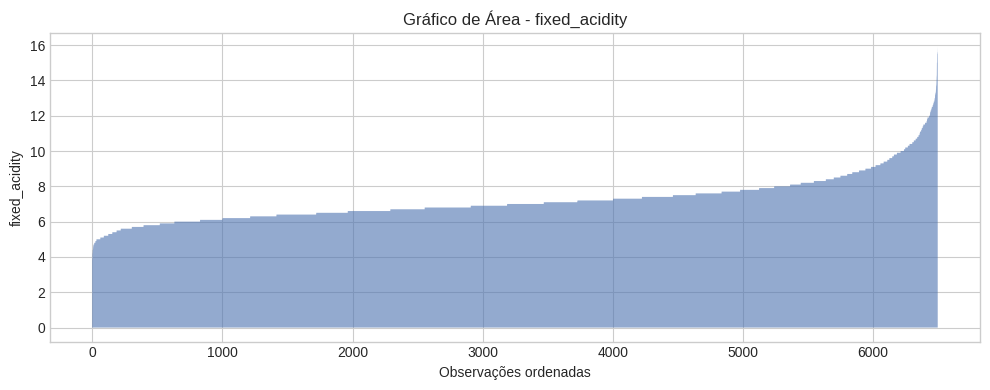

Comentário sobre fixed_acidity:
- O gráfico de área reforça visualmente a concentração dos valores de 'fixed_acidity'.
- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.
- Também ajuda a perceber se a variável está concentrada em faixa estreita ou se apresenta grande dispersão.



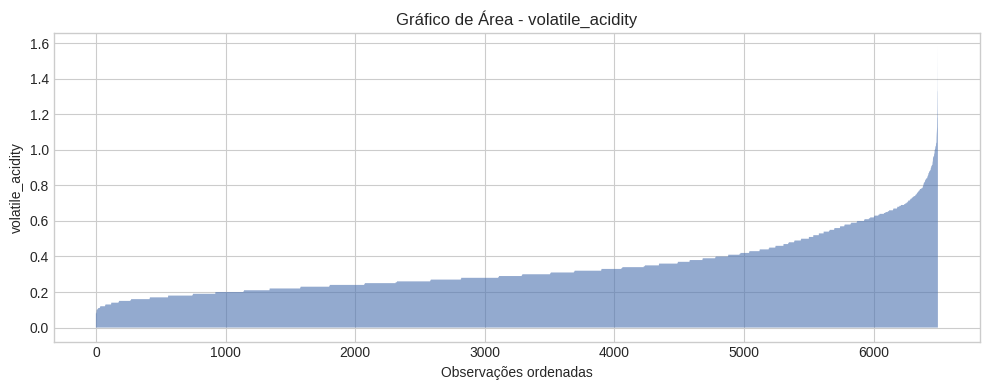

Comentário sobre volatile_acidity:
- O gráfico de área reforça visualmente a concentração dos valores de 'volatile_acidity'.
- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.
- Também ajuda a perceber se a variável está concentrada em faixa estreita ou se apresenta grande dispersão.



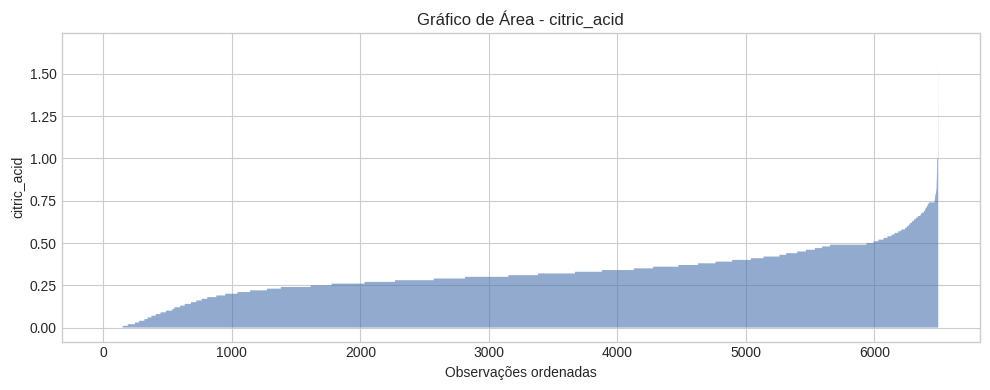

Comentário sobre citric_acid:
- O gráfico de área reforça visualmente a concentração dos valores de 'citric_acid'.
- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.
- Também ajuda a perceber se a variável está concentrada em faixa estreita ou se apresenta grande dispersão.



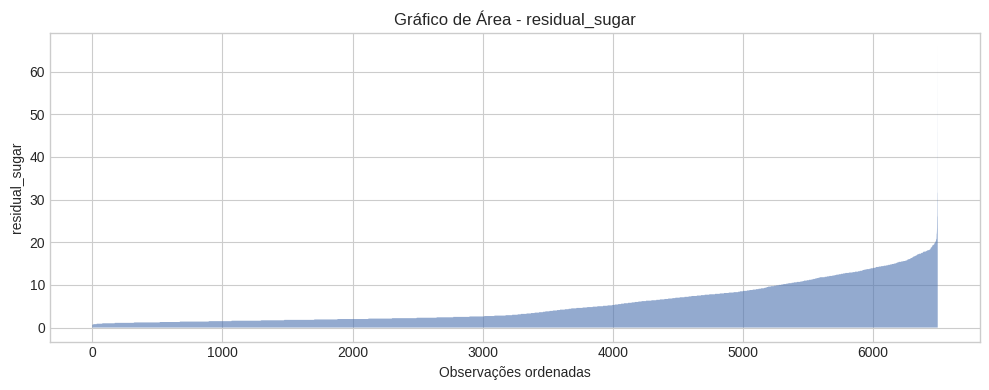

Comentário sobre residual_sugar:
- O gráfico de área reforça visualmente a concentração dos valores de 'residual_sugar'.
- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.
- Também ajuda a perceber se a variável está concentrada em faixa estreita ou se apresenta grande dispersão.



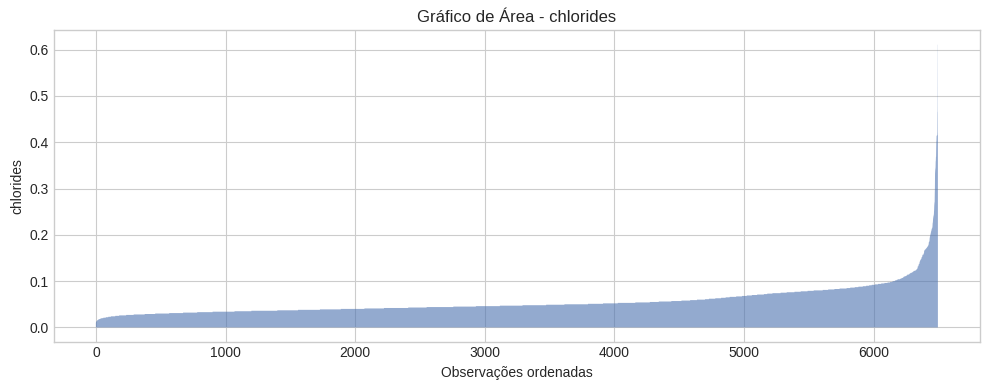

Comentário sobre chlorides:
- O gráfico de área reforça visualmente a concentração dos valores de 'chlorides'.
- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.
- Também ajuda a perceber se a variável está concentrada em faixa estreita ou se apresenta grande dispersão.



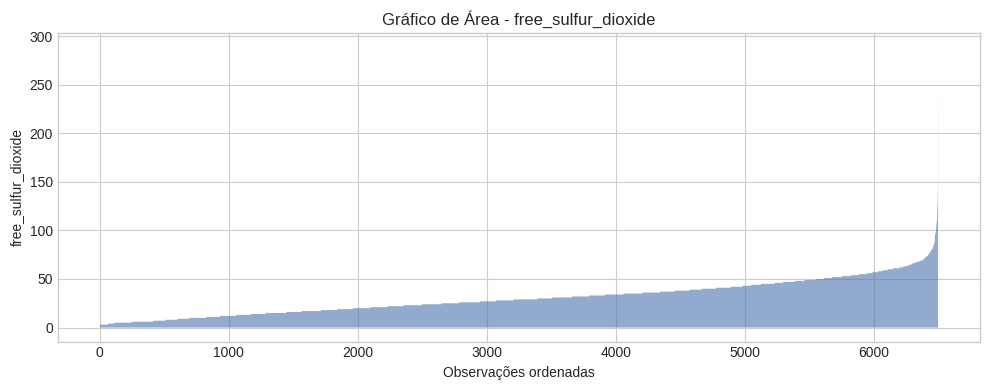

Comentário sobre free_sulfur_dioxide:
- O gráfico de área reforça visualmente a concentração dos valores de 'free_sulfur_dioxide'.
- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.
- Também ajuda a perceber se a variável está concentrada em faixa estreita ou se apresenta grande dispersão.



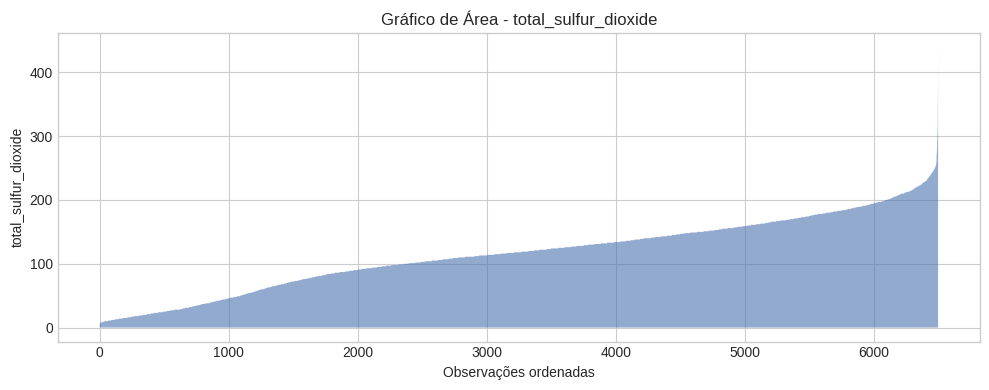

Comentário sobre total_sulfur_dioxide:
- O gráfico de área reforça visualmente a concentração dos valores de 'total_sulfur_dioxide'.
- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.
- Também ajuda a perceber se a variável está concentrada em faixa estreita ou se apresenta grande dispersão.



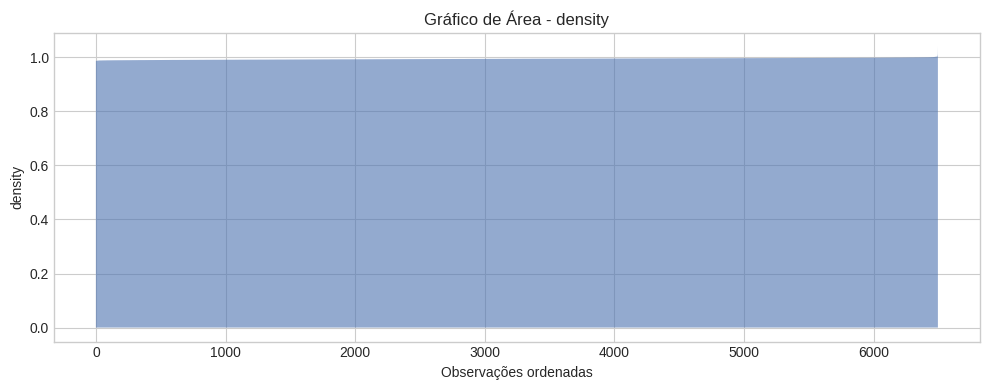

Comentário sobre density:
- O gráfico de área reforça visualmente a concentração dos valores de 'density'.
- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.
- Também ajuda a perceber se a variável está concentrada em faixa estreita ou se apresenta grande dispersão.



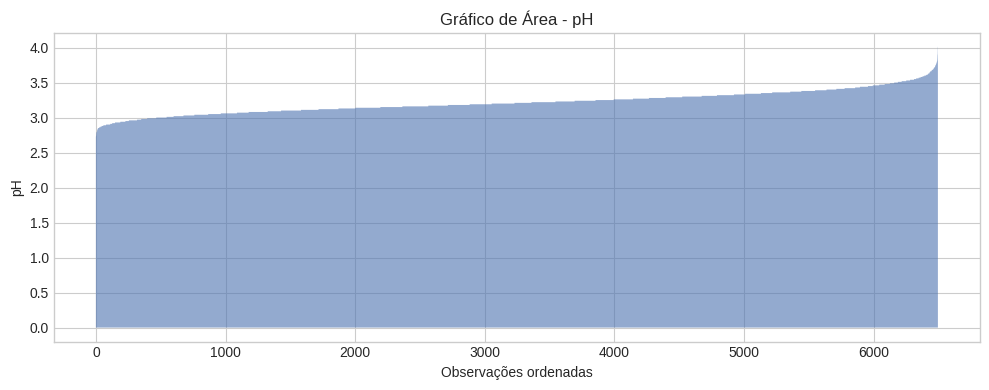

Comentário sobre pH:
- O gráfico de área reforça visualmente a concentração dos valores de 'pH'.
- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.
- Também ajuda a perceber se a variável está concentrada em faixa estreita ou se apresenta grande dispersão.



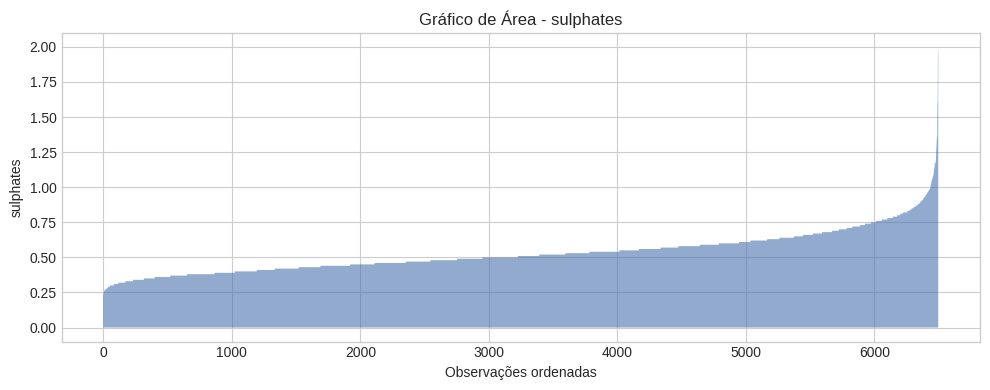

Comentário sobre sulphates:
- O gráfico de área reforça visualmente a concentração dos valores de 'sulphates'.
- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.
- Também ajuda a perceber se a variável está concentrada em faixa estreita ou se apresenta grande dispersão.



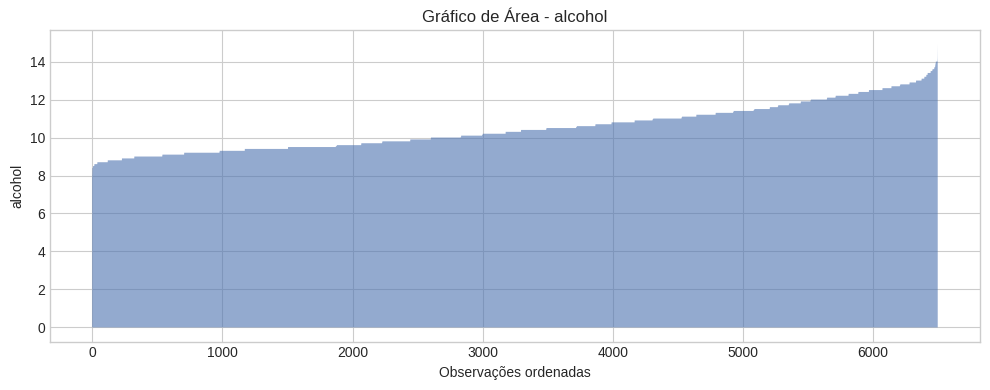

Comentário sobre alcohol:
- O gráfico de área reforça visualmente a concentração dos valores de 'alcohol'.
- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.
- Também ajuda a perceber se a variável está concentrada em faixa estreita ou se apresenta grande dispersão.



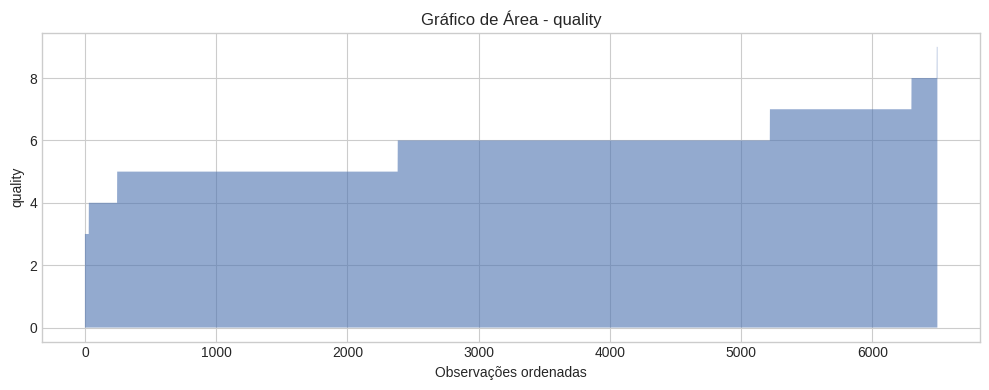

Comentário sobre quality:
- O gráfico de área reforça visualmente a concentração dos valores de 'quality'.
- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.
- Também ajuda a perceber se a variável está concentrada em faixa estreita ou se apresenta grande dispersão.



In [14]:
for var in variaveis:
    plt.figure(figsize=(10, 4))

    serie_ordenada = df[var].sort_values().reset_index(drop=True)
    plt.fill_between(range(len(serie_ordenada)), serie_ordenada, alpha=0.6)

    plt.title(f"Gráfico de Área - {var}")
    plt.xlabel("Observações ordenadas")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

    print(f"Comentário sobre {var}:")
    print(
        f"- O gráfico de área reforça visualmente a concentração dos valores de '{var}'.\n"
        f"- Áreas mais densas sugerem maior acúmulo de observações em determinados níveis.\n"
        f"- Também ajuda a perceber se a variável está concentrada em faixa estreita "
        f"ou se apresenta grande dispersão.\n"
    )

# Gráfico de barras

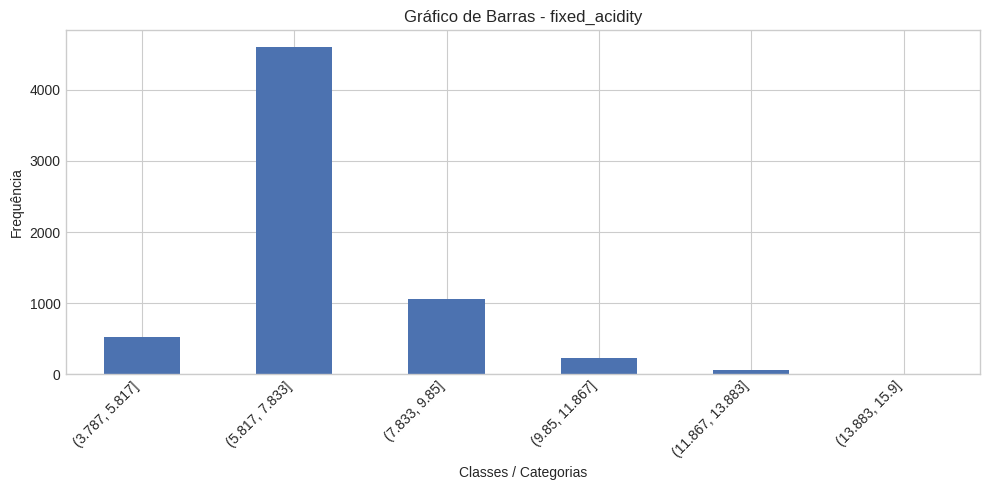

Comentário sobre fixed_acidity:
- O gráfico de barras de 'fixed_acidity' permite comparar a frequência entre classes ou categorias.
- Barras mais altas indicam maior ocorrência.
- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; para variáveis categóricas, foram usadas as categorias originais.



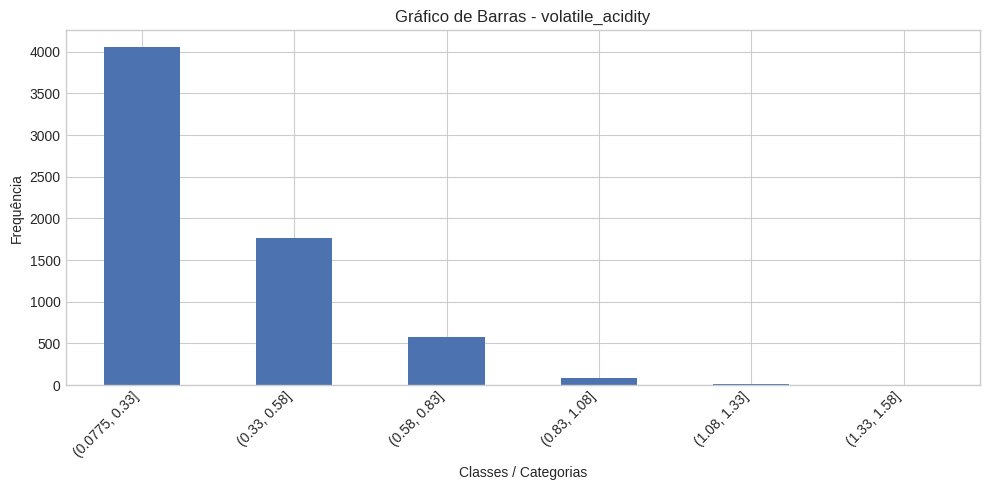

Comentário sobre volatile_acidity:
- O gráfico de barras de 'volatile_acidity' permite comparar a frequência entre classes ou categorias.
- Barras mais altas indicam maior ocorrência.
- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; para variáveis categóricas, foram usadas as categorias originais.



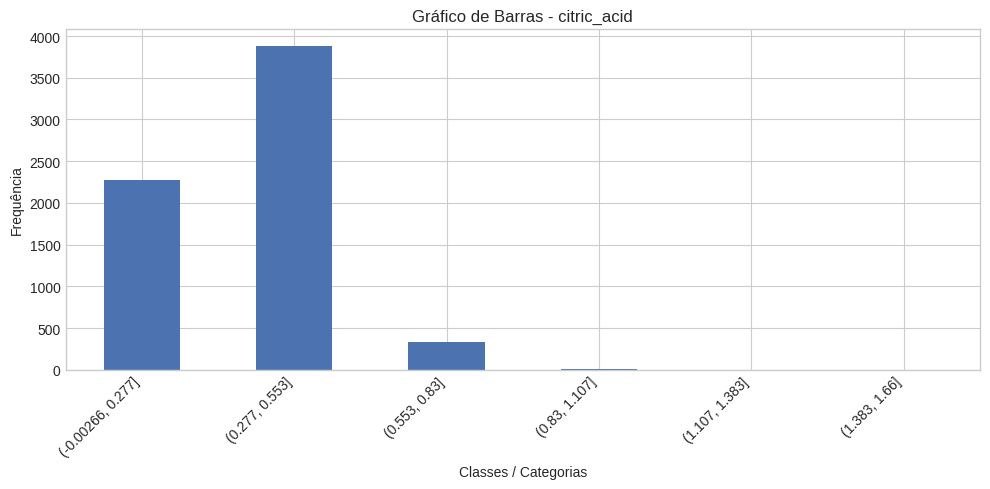

Comentário sobre citric_acid:
- O gráfico de barras de 'citric_acid' permite comparar a frequência entre classes ou categorias.
- Barras mais altas indicam maior ocorrência.
- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; para variáveis categóricas, foram usadas as categorias originais.



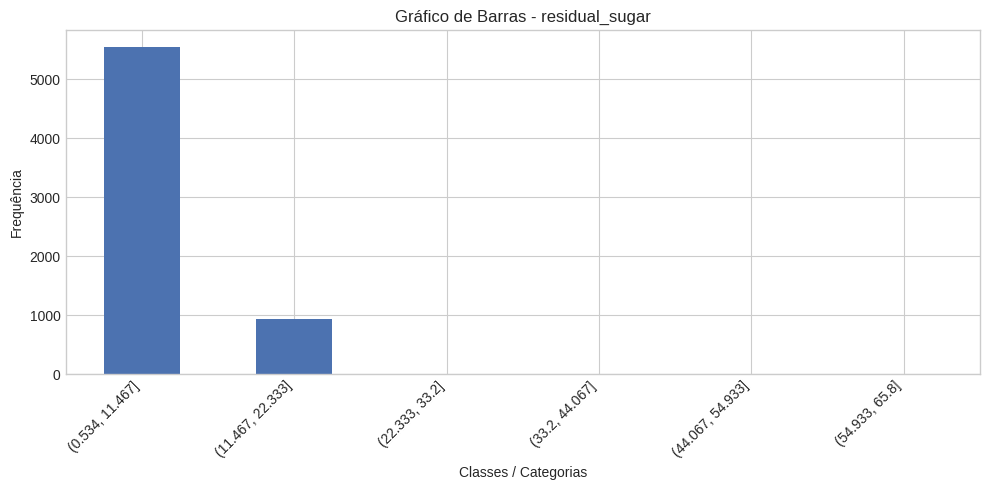

Comentário sobre residual_sugar:
- O gráfico de barras de 'residual_sugar' permite comparar a frequência entre classes ou categorias.
- Barras mais altas indicam maior ocorrência.
- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; para variáveis categóricas, foram usadas as categorias originais.



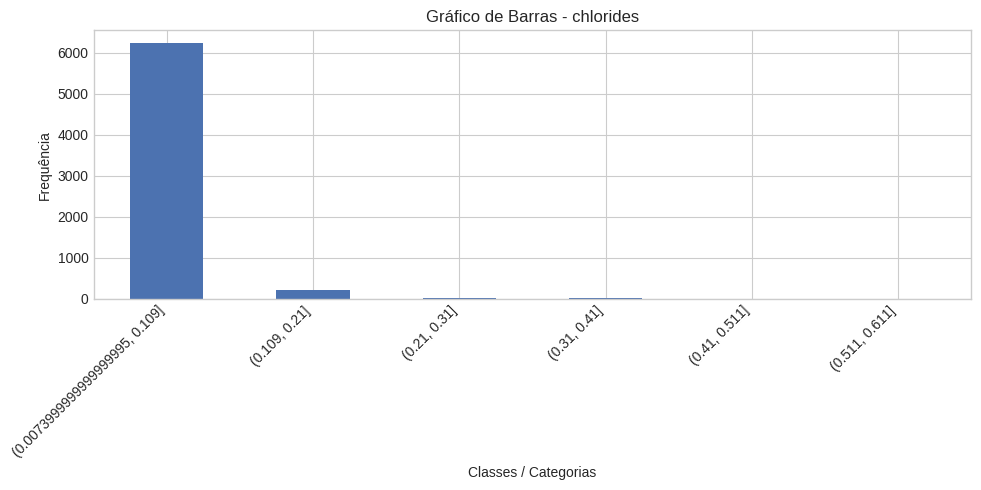

Comentário sobre chlorides:
- O gráfico de barras de 'chlorides' permite comparar a frequência entre classes ou categorias.
- Barras mais altas indicam maior ocorrência.
- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; para variáveis categóricas, foram usadas as categorias originais.



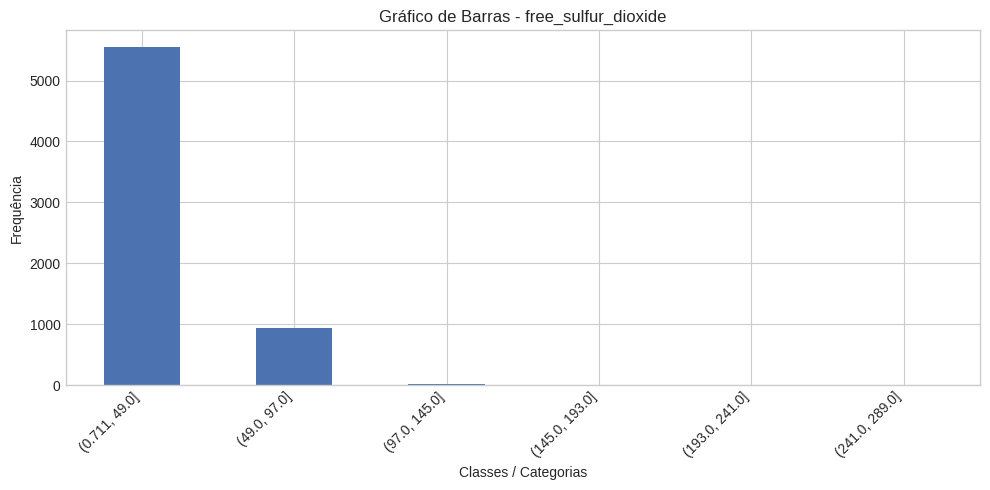

Comentário sobre free_sulfur_dioxide:
- O gráfico de barras de 'free_sulfur_dioxide' permite comparar a frequência entre classes ou categorias.
- Barras mais altas indicam maior ocorrência.
- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; para variáveis categóricas, foram usadas as categorias originais.



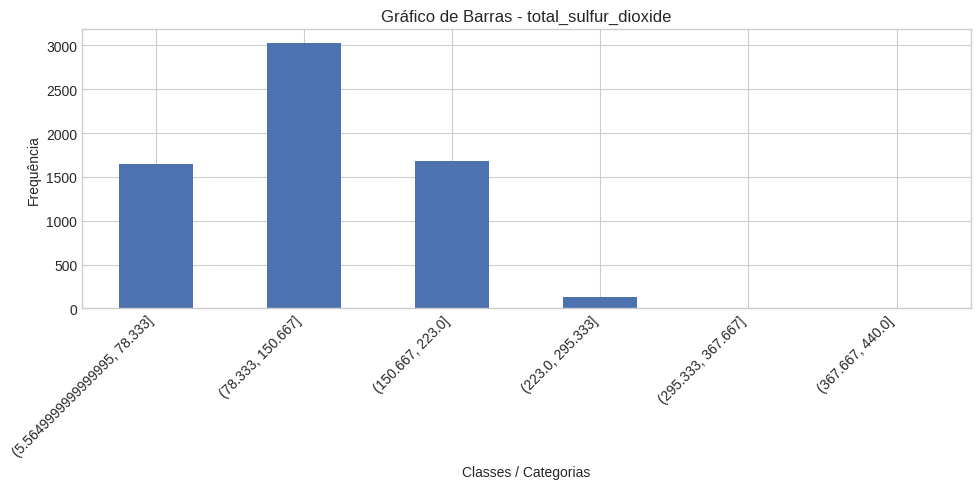

Comentário sobre total_sulfur_dioxide:
- O gráfico de barras de 'total_sulfur_dioxide' permite comparar a frequência entre classes ou categorias.
- Barras mais altas indicam maior ocorrência.
- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; para variáveis categóricas, foram usadas as categorias originais.



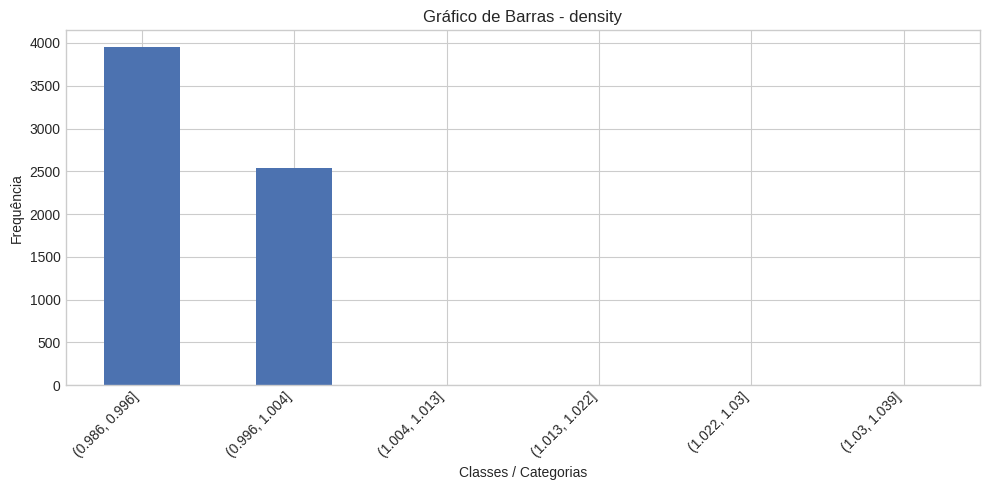

Comentário sobre density:
- O gráfico de barras de 'density' permite comparar a frequência entre classes ou categorias.
- Barras mais altas indicam maior ocorrência.
- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; para variáveis categóricas, foram usadas as categorias originais.



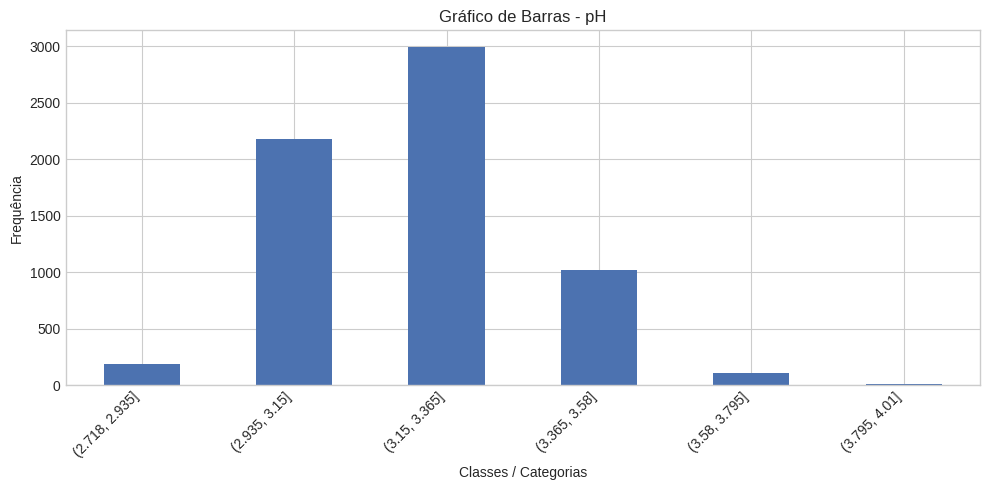

Comentário sobre pH:
- O gráfico de barras de 'pH' permite comparar a frequência entre classes ou categorias.
- Barras mais altas indicam maior ocorrência.
- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; para variáveis categóricas, foram usadas as categorias originais.



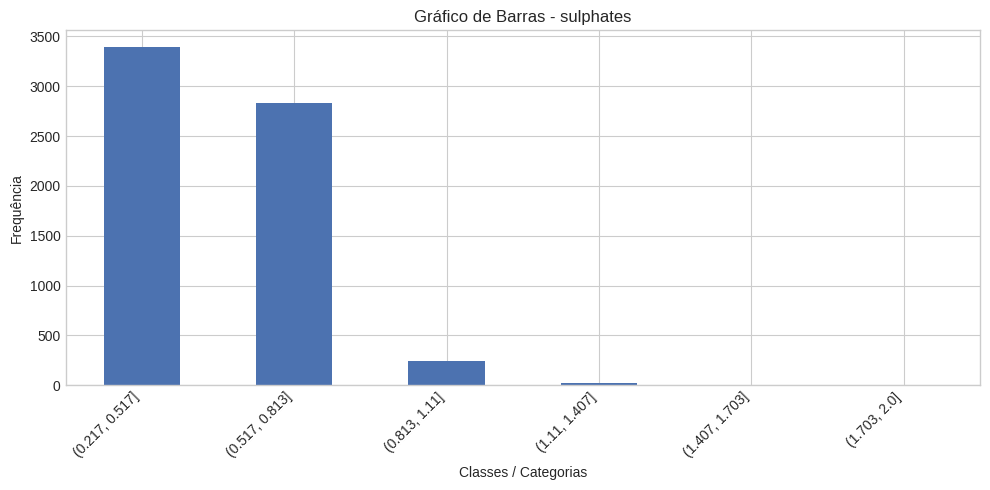

Comentário sobre sulphates:
- O gráfico de barras de 'sulphates' permite comparar a frequência entre classes ou categorias.
- Barras mais altas indicam maior ocorrência.
- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; para variáveis categóricas, foram usadas as categorias originais.



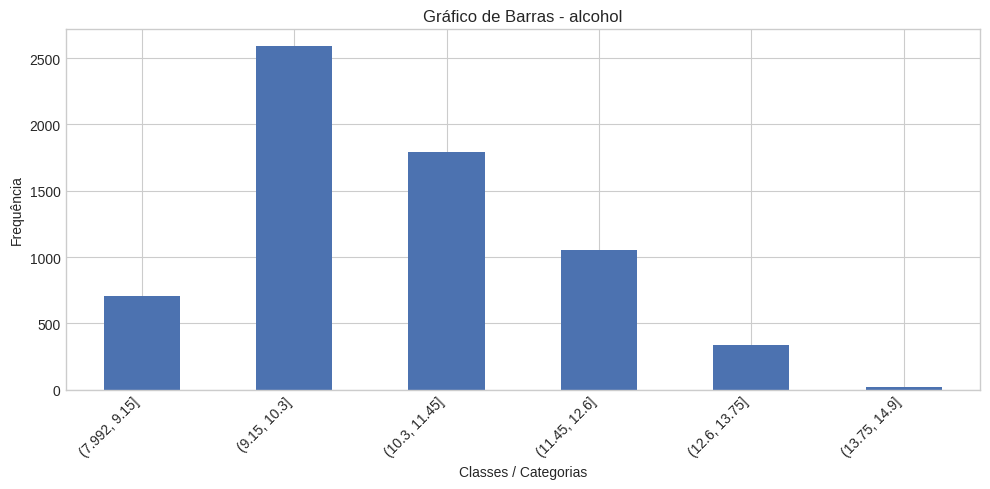

Comentário sobre alcohol:
- O gráfico de barras de 'alcohol' permite comparar a frequência entre classes ou categorias.
- Barras mais altas indicam maior ocorrência.
- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; para variáveis categóricas, foram usadas as categorias originais.



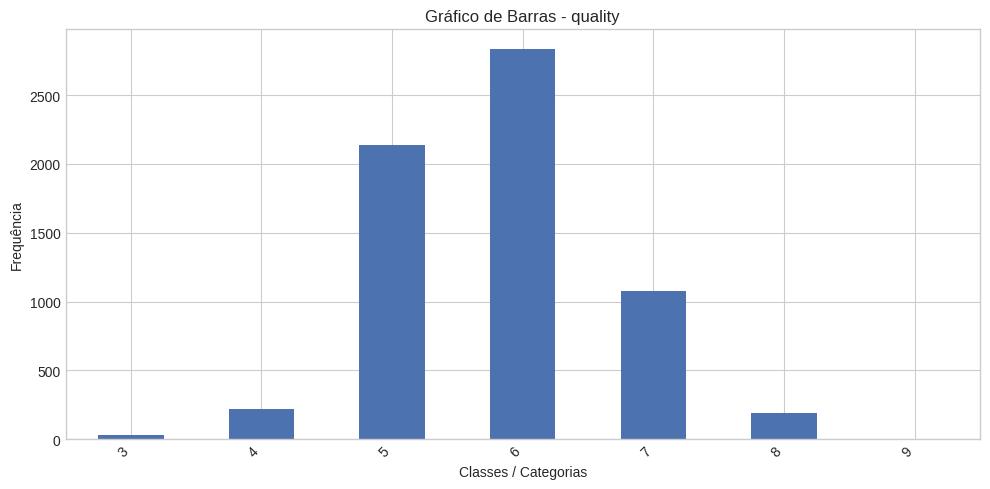

Comentário sobre quality:
- O gráfico de barras de 'quality' permite comparar a frequência entre classes ou categorias.
- Barras mais altas indicam maior ocorrência.
- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; para variáveis categóricas, foram usadas as categorias originais.



In [15]:
from pandas.api.types import is_numeric_dtype

for var in variaveis:
    plt.figure(figsize=(10, 5))

    if is_numeric_dtype(df[var]):
        # Se for quality e tiver poucos valores únicos, usa valores diretos
        if var == "quality" or df[var].nunique() <= 10:
            freq = df[var].value_counts().sort_index()
        else:
            freq = criar_classes_serie(df[var], bins=6)
    else:
        # Se for texto/categórica
        freq = df[var].value_counts()

    freq.plot(kind="bar")

    plt.title(f"Gráfico de Barras - {var}")
    plt.xlabel("Classes / Categorias")
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    print(f"Comentário sobre {var}:")
    print(
        f"- O gráfico de barras de '{var}' permite comparar a frequência entre classes ou categorias.\n"
        f"- Barras mais altas indicam maior ocorrência.\n"
        f"- Para variáveis numéricas contínuas, os valores foram agrupados em faixas; "
        f"para variáveis categóricas, foram usadas as categorias originais.\n"
    )

# Histograma

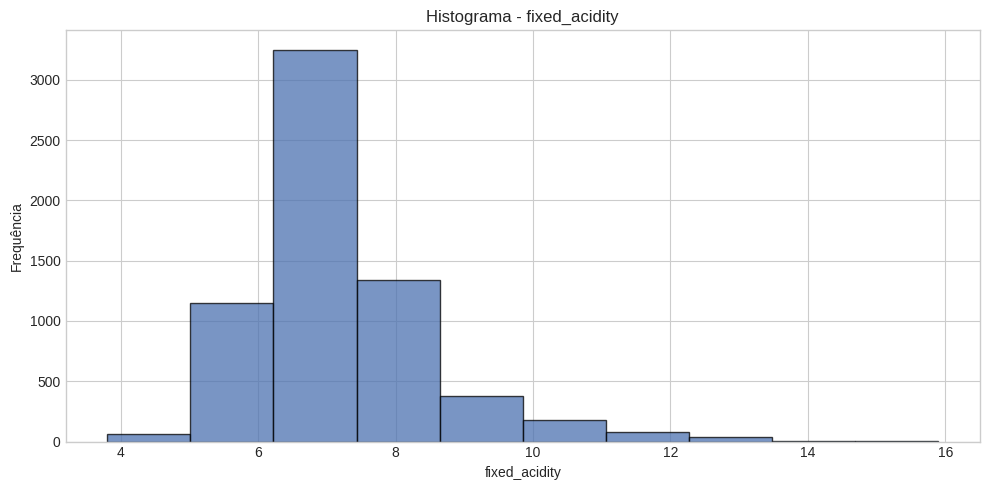

Comentário sobre fixed_acidity:
- O histograma de 'fixed_acidity' mostra como os dados se distribuem em intervalos.
- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.
- Se as barras centrais predominarem, há concentração em torno de valores médios; se houver barras isoladas nas extremidades, pode haver outliers.



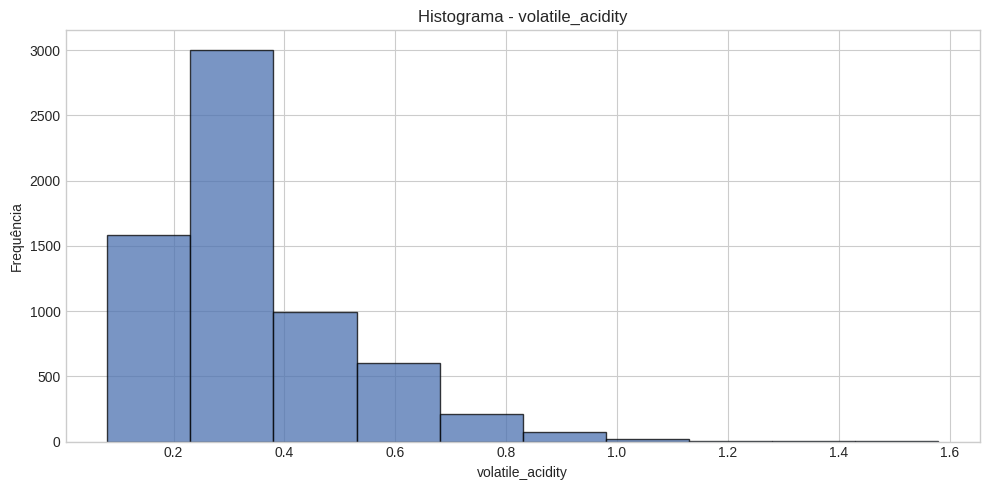

Comentário sobre volatile_acidity:
- O histograma de 'volatile_acidity' mostra como os dados se distribuem em intervalos.
- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.
- Se as barras centrais predominarem, há concentração em torno de valores médios; se houver barras isoladas nas extremidades, pode haver outliers.



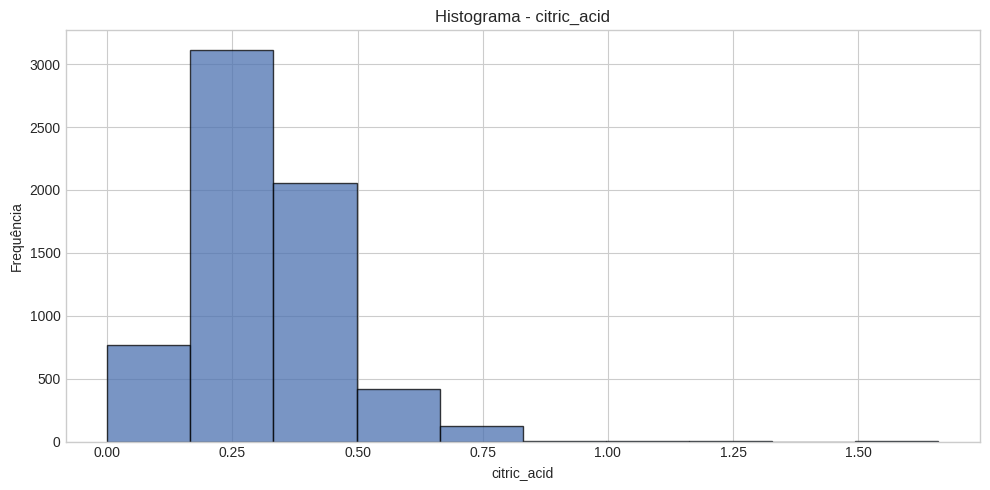

Comentário sobre citric_acid:
- O histograma de 'citric_acid' mostra como os dados se distribuem em intervalos.
- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.
- Se as barras centrais predominarem, há concentração em torno de valores médios; se houver barras isoladas nas extremidades, pode haver outliers.



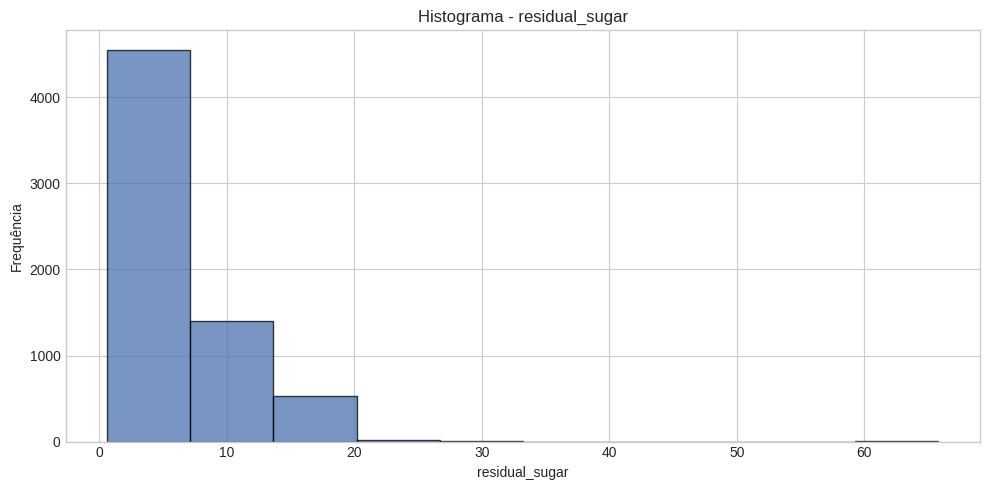

Comentário sobre residual_sugar:
- O histograma de 'residual_sugar' mostra como os dados se distribuem em intervalos.
- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.
- Se as barras centrais predominarem, há concentração em torno de valores médios; se houver barras isoladas nas extremidades, pode haver outliers.



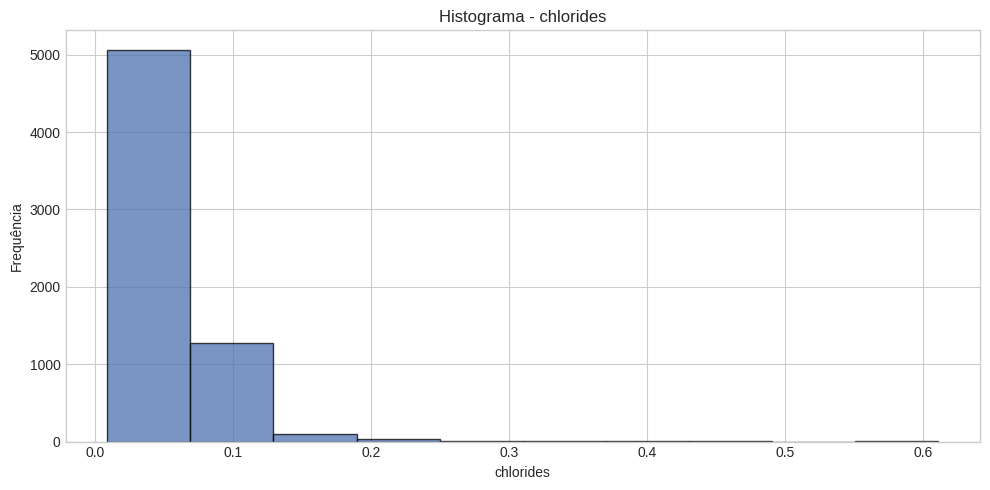

Comentário sobre chlorides:
- O histograma de 'chlorides' mostra como os dados se distribuem em intervalos.
- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.
- Se as barras centrais predominarem, há concentração em torno de valores médios; se houver barras isoladas nas extremidades, pode haver outliers.



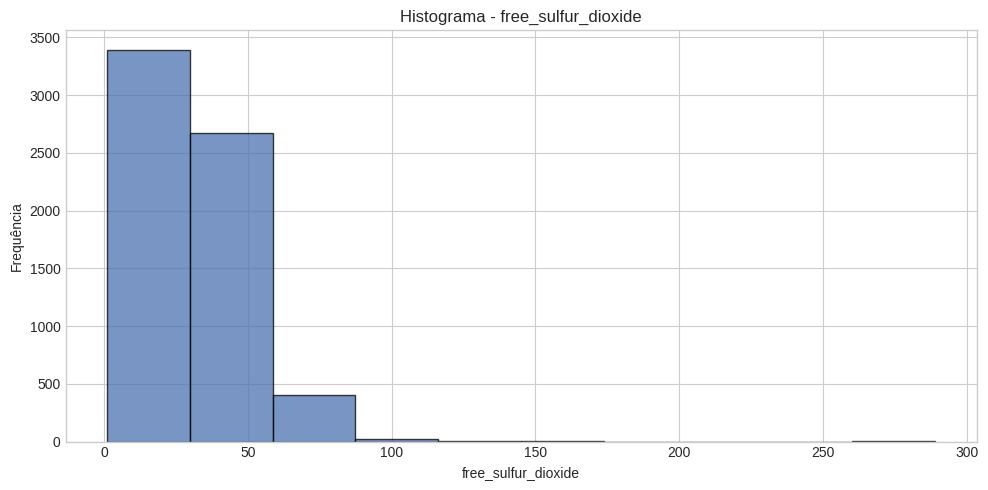

Comentário sobre free_sulfur_dioxide:
- O histograma de 'free_sulfur_dioxide' mostra como os dados se distribuem em intervalos.
- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.
- Se as barras centrais predominarem, há concentração em torno de valores médios; se houver barras isoladas nas extremidades, pode haver outliers.



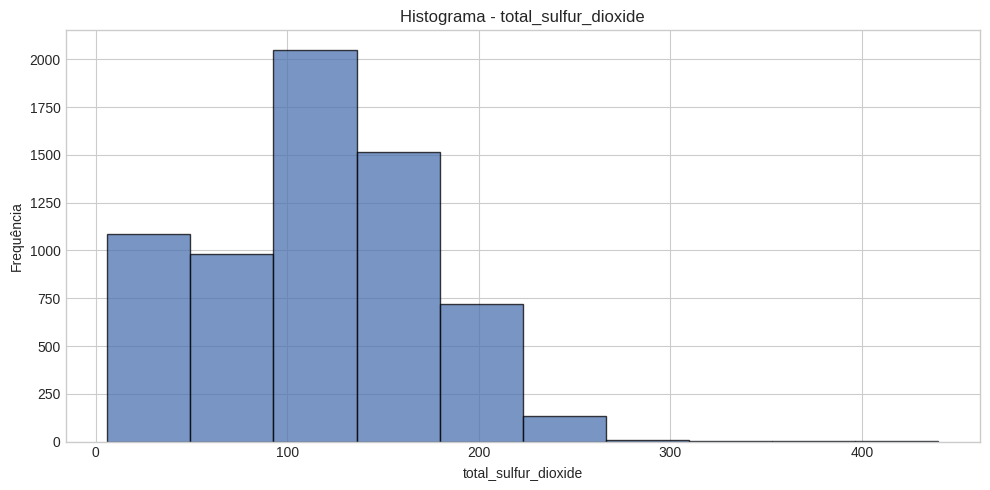

Comentário sobre total_sulfur_dioxide:
- O histograma de 'total_sulfur_dioxide' mostra como os dados se distribuem em intervalos.
- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.
- Se as barras centrais predominarem, há concentração em torno de valores médios; se houver barras isoladas nas extremidades, pode haver outliers.



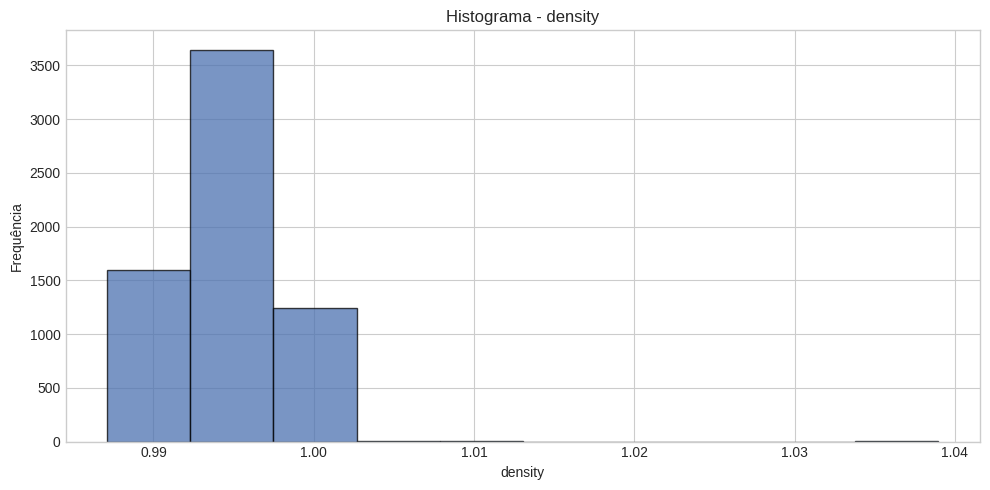

Comentário sobre density:
- O histograma de 'density' mostra como os dados se distribuem em intervalos.
- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.
- Se as barras centrais predominarem, há concentração em torno de valores médios; se houver barras isoladas nas extremidades, pode haver outliers.



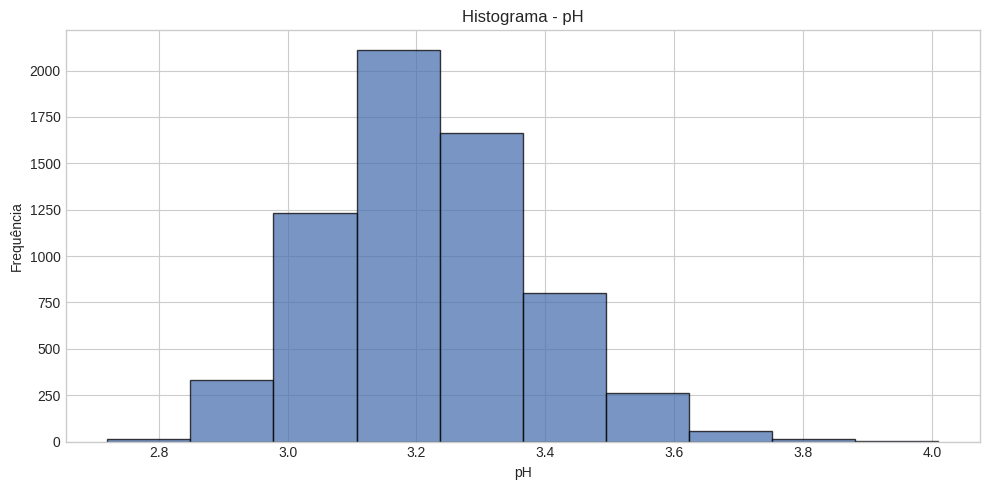

Comentário sobre pH:
- O histograma de 'pH' mostra como os dados se distribuem em intervalos.
- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.
- Se as barras centrais predominarem, há concentração em torno de valores médios; se houver barras isoladas nas extremidades, pode haver outliers.



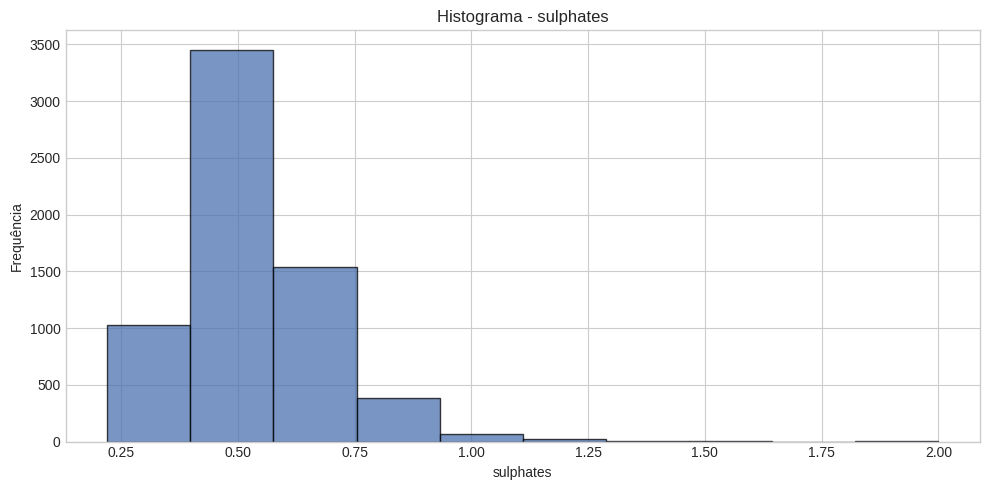

Comentário sobre sulphates:
- O histograma de 'sulphates' mostra como os dados se distribuem em intervalos.
- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.
- Se as barras centrais predominarem, há concentração em torno de valores médios; se houver barras isoladas nas extremidades, pode haver outliers.



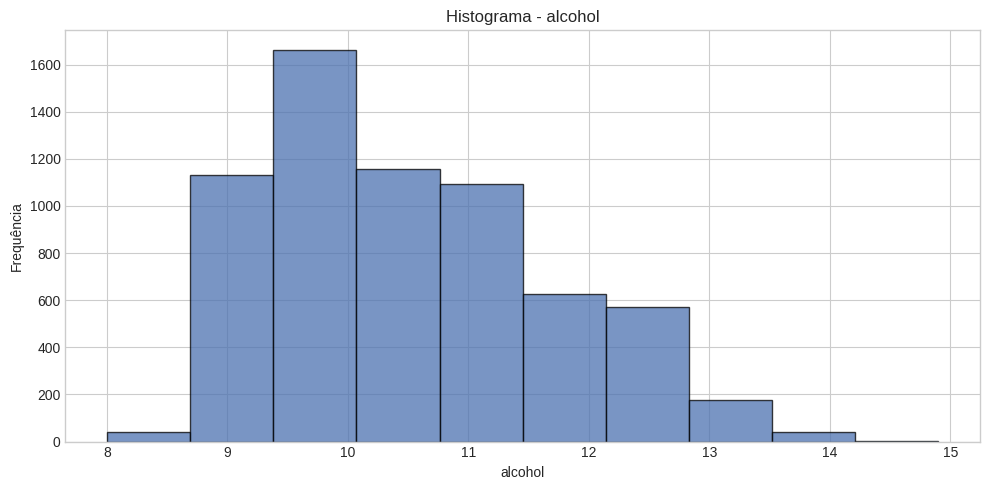

Comentário sobre alcohol:
- O histograma de 'alcohol' mostra como os dados se distribuem em intervalos.
- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.
- Se as barras centrais predominarem, há concentração em torno de valores médios; se houver barras isoladas nas extremidades, pode haver outliers.



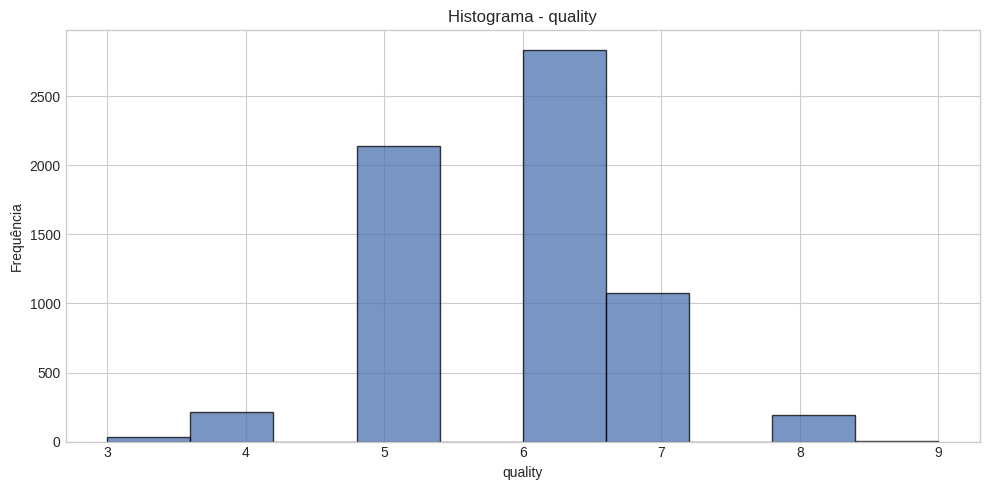

Comentário sobre quality:
- O histograma de 'quality' mostra como os dados se distribuem em intervalos.
- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.
- Se as barras centrais predominarem, há concentração em torno de valores médios; se houver barras isoladas nas extremidades, pode haver outliers.



In [16]:
for var in variaveis:
    plt.figure(figsize=(10, 5))

    plt.hist(df[var], bins=10, edgecolor="black", alpha=0.75)
    plt.title(f"Histograma - {var}")
    plt.xlabel(var)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

    print(f"Comentário sobre {var}:")
    print(
        f"- O histograma de '{var}' mostra como os dados se distribuem em intervalos.\n"
        f"- Ele permite observar concentração, dispersão, assimetria e possíveis caudas longas.\n"
        f"- Se as barras centrais predominarem, há concentração em torno de valores médios; "
        f"se houver barras isoladas nas extremidades, pode haver outliers.\n"
    )

# Gráfico de dispersão

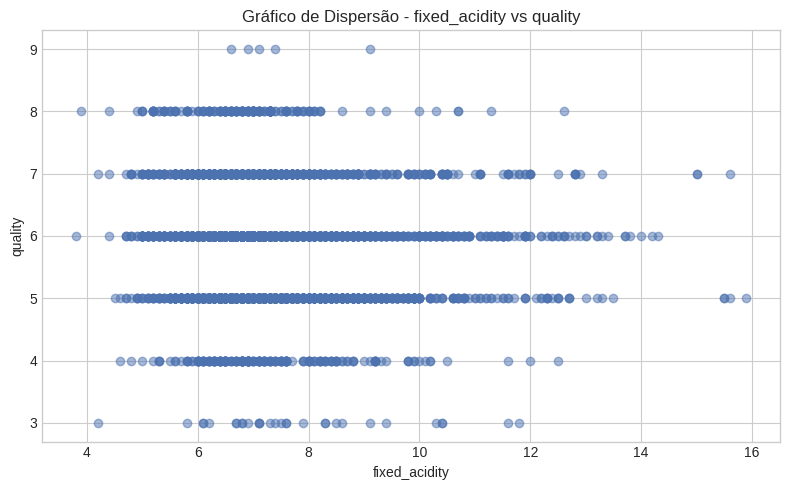

Comentário sobre fixed_acidity vs quality:
- O gráfico de dispersão mostra a relação entre 'fixed_acidity' e 'quality'.
- Se os pontos sugerirem inclinação crescente, pode existir relação positiva; se inclinarem para baixo, relação negativa.
- Se os pontos estiverem muito espalhados, a relação tende a ser fraca.



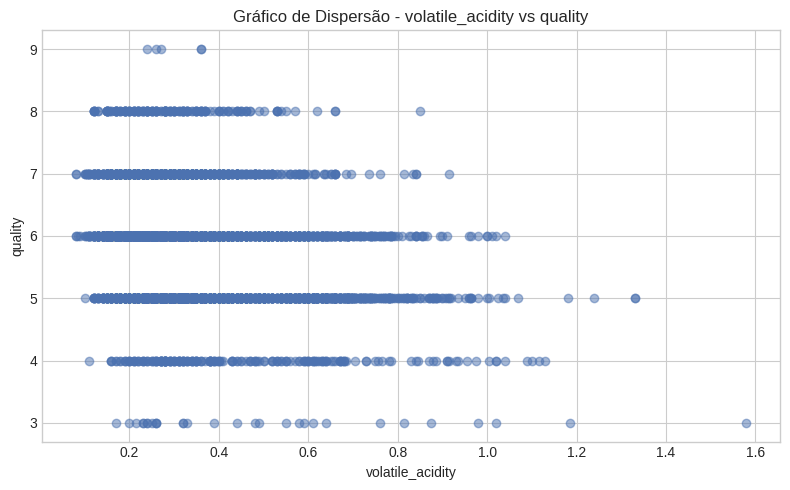

Comentário sobre volatile_acidity vs quality:
- O gráfico de dispersão mostra a relação entre 'volatile_acidity' e 'quality'.
- Se os pontos sugerirem inclinação crescente, pode existir relação positiva; se inclinarem para baixo, relação negativa.
- Se os pontos estiverem muito espalhados, a relação tende a ser fraca.



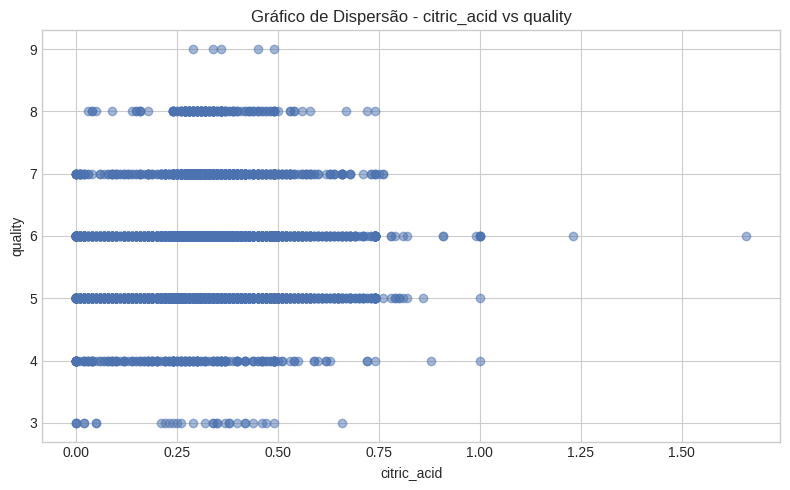

Comentário sobre citric_acid vs quality:
- O gráfico de dispersão mostra a relação entre 'citric_acid' e 'quality'.
- Se os pontos sugerirem inclinação crescente, pode existir relação positiva; se inclinarem para baixo, relação negativa.
- Se os pontos estiverem muito espalhados, a relação tende a ser fraca.



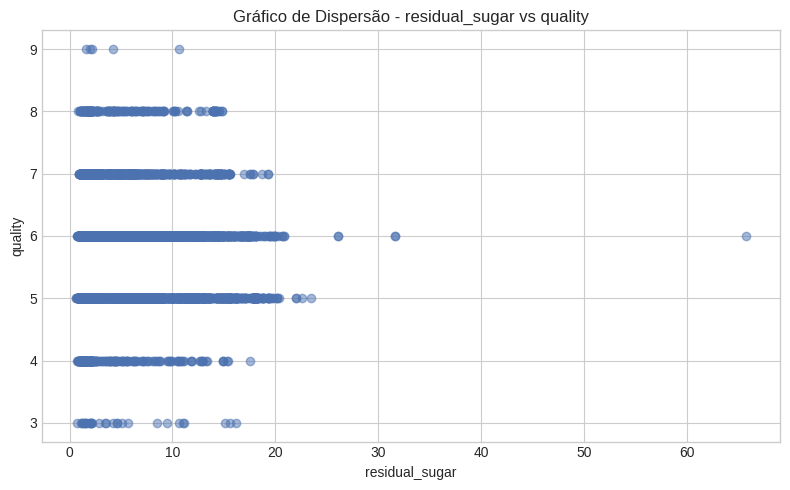

Comentário sobre residual_sugar vs quality:
- O gráfico de dispersão mostra a relação entre 'residual_sugar' e 'quality'.
- Se os pontos sugerirem inclinação crescente, pode existir relação positiva; se inclinarem para baixo, relação negativa.
- Se os pontos estiverem muito espalhados, a relação tende a ser fraca.



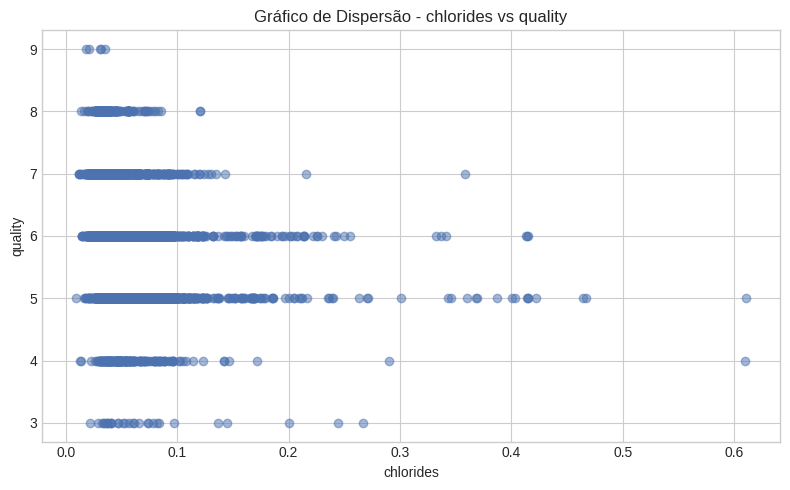

Comentário sobre chlorides vs quality:
- O gráfico de dispersão mostra a relação entre 'chlorides' e 'quality'.
- Se os pontos sugerirem inclinação crescente, pode existir relação positiva; se inclinarem para baixo, relação negativa.
- Se os pontos estiverem muito espalhados, a relação tende a ser fraca.



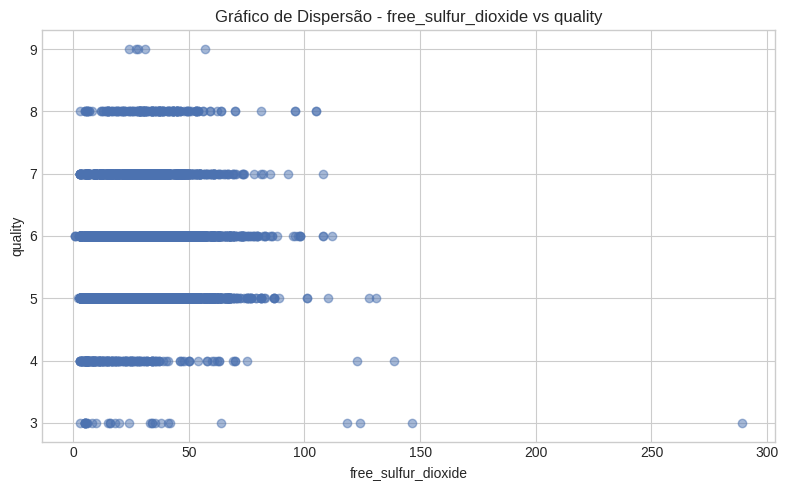

Comentário sobre free_sulfur_dioxide vs quality:
- O gráfico de dispersão mostra a relação entre 'free_sulfur_dioxide' e 'quality'.
- Se os pontos sugerirem inclinação crescente, pode existir relação positiva; se inclinarem para baixo, relação negativa.
- Se os pontos estiverem muito espalhados, a relação tende a ser fraca.



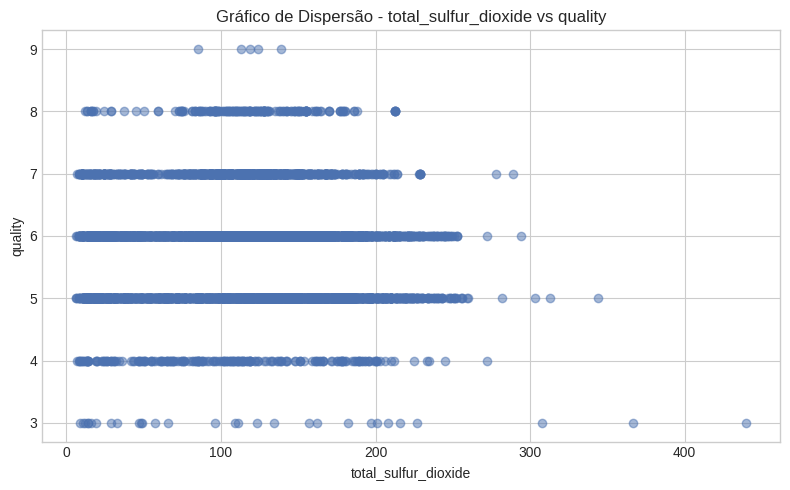

Comentário sobre total_sulfur_dioxide vs quality:
- O gráfico de dispersão mostra a relação entre 'total_sulfur_dioxide' e 'quality'.
- Se os pontos sugerirem inclinação crescente, pode existir relação positiva; se inclinarem para baixo, relação negativa.
- Se os pontos estiverem muito espalhados, a relação tende a ser fraca.



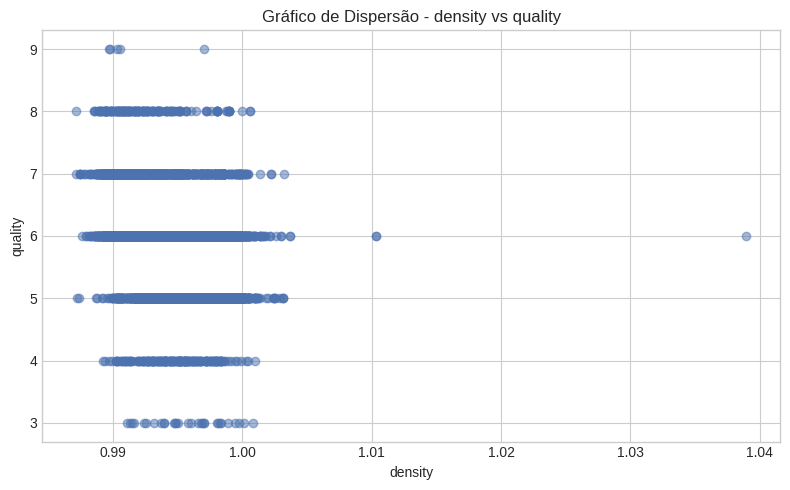

Comentário sobre density vs quality:
- O gráfico de dispersão mostra a relação entre 'density' e 'quality'.
- Se os pontos sugerirem inclinação crescente, pode existir relação positiva; se inclinarem para baixo, relação negativa.
- Se os pontos estiverem muito espalhados, a relação tende a ser fraca.



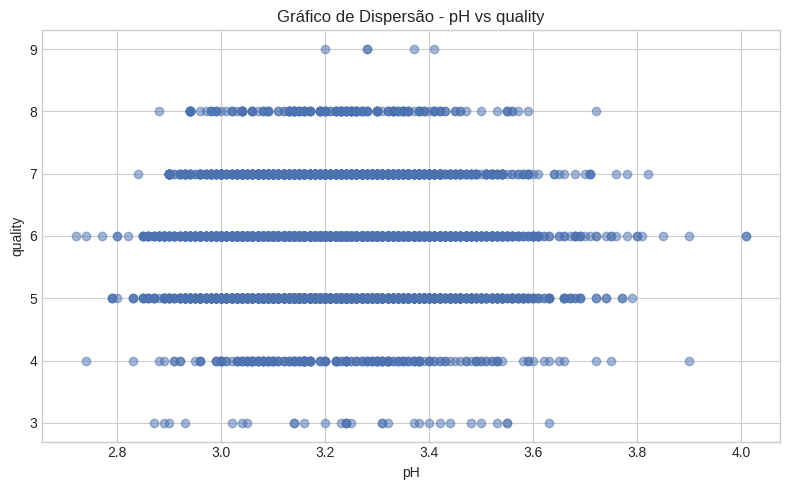

Comentário sobre pH vs quality:
- O gráfico de dispersão mostra a relação entre 'pH' e 'quality'.
- Se os pontos sugerirem inclinação crescente, pode existir relação positiva; se inclinarem para baixo, relação negativa.
- Se os pontos estiverem muito espalhados, a relação tende a ser fraca.



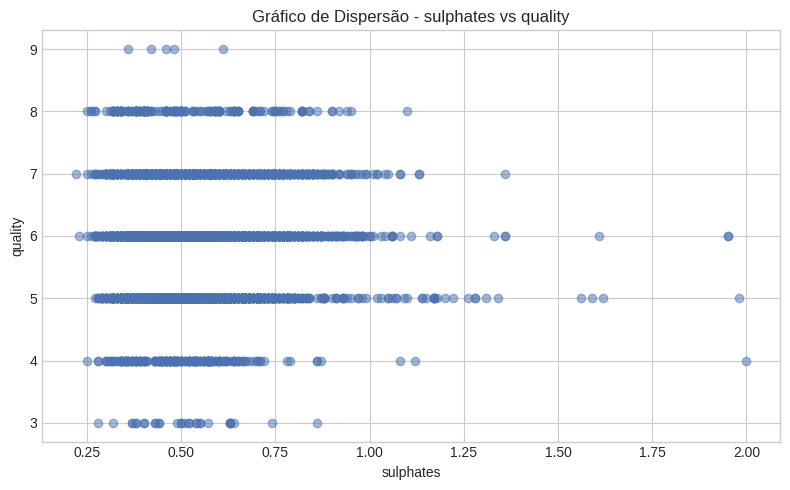

Comentário sobre sulphates vs quality:
- O gráfico de dispersão mostra a relação entre 'sulphates' e 'quality'.
- Se os pontos sugerirem inclinação crescente, pode existir relação positiva; se inclinarem para baixo, relação negativa.
- Se os pontos estiverem muito espalhados, a relação tende a ser fraca.



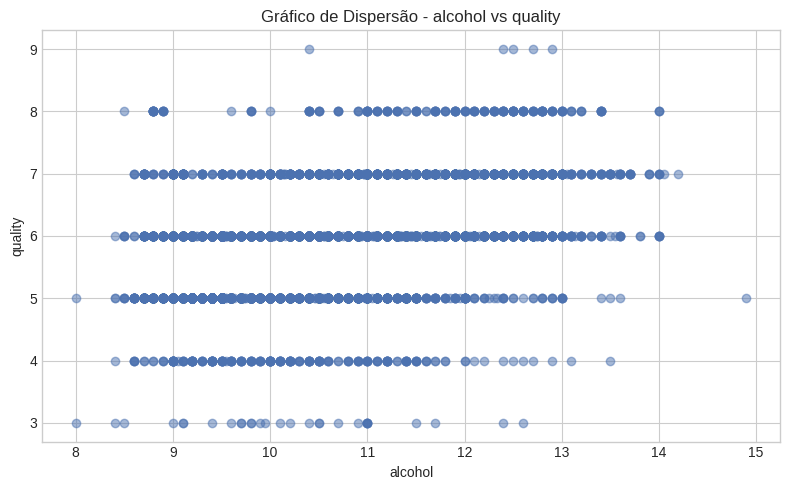

Comentário sobre alcohol vs quality:
- O gráfico de dispersão mostra a relação entre 'alcohol' e 'quality'.
- Se os pontos sugerirem inclinação crescente, pode existir relação positiva; se inclinarem para baixo, relação negativa.
- Se os pontos estiverem muito espalhados, a relação tende a ser fraca.



In [17]:
for var in variaveis:
    if var != "quality":
        plt.figure(figsize=(8, 5))

        plt.scatter(df[var], df["quality"], alpha=0.5)
        plt.title(f"Gráfico de Dispersão - {var} vs quality")
        plt.xlabel(var)
        plt.ylabel("quality")
        plt.tight_layout()
        plt.show()

        print(f"Comentário sobre {var} vs quality:")
        print(
            f"- O gráfico de dispersão mostra a relação entre '{var}' e 'quality'.\n"
            f"- Se os pontos sugerirem inclinação crescente, pode existir relação positiva; "
            f"se inclinarem para baixo, relação negativa.\n"
            f"- Se os pontos estiverem muito espalhados, a relação tende a ser fraca.\n"
        )

# Gráfico de caixa

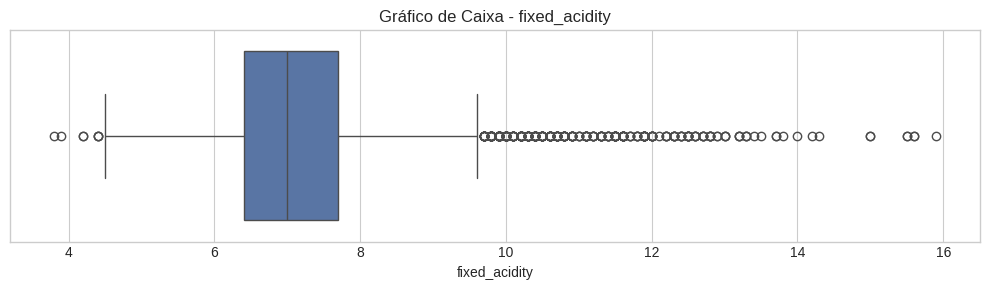

Comentário sobre fixed_acidity:
- O boxplot de 'fixed_acidity' evidencia a mediana, o intervalo interquartil e os valores extremos.
- Pontos fora dos limites da caixa indicam possíveis outliers.
- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.



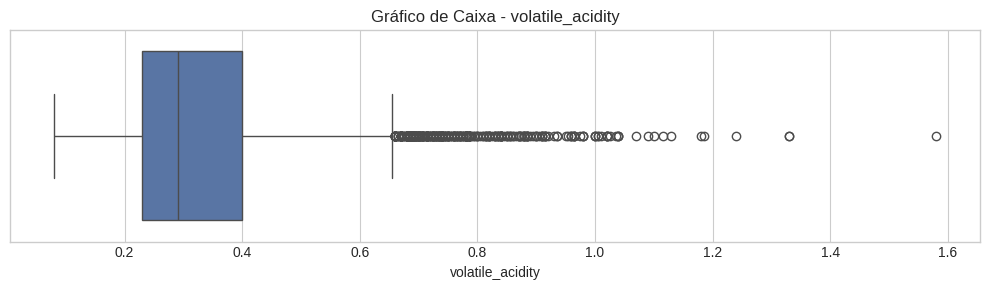

Comentário sobre volatile_acidity:
- O boxplot de 'volatile_acidity' evidencia a mediana, o intervalo interquartil e os valores extremos.
- Pontos fora dos limites da caixa indicam possíveis outliers.
- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.



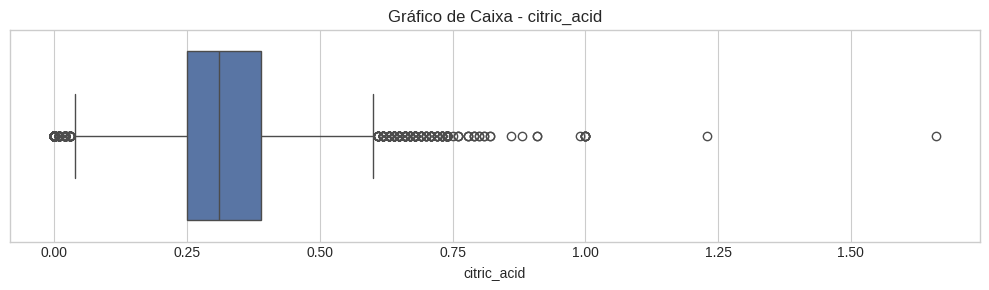

Comentário sobre citric_acid:
- O boxplot de 'citric_acid' evidencia a mediana, o intervalo interquartil e os valores extremos.
- Pontos fora dos limites da caixa indicam possíveis outliers.
- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.



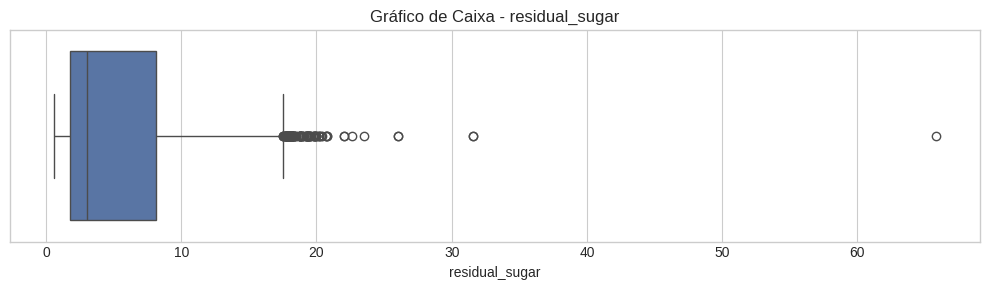

Comentário sobre residual_sugar:
- O boxplot de 'residual_sugar' evidencia a mediana, o intervalo interquartil e os valores extremos.
- Pontos fora dos limites da caixa indicam possíveis outliers.
- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.



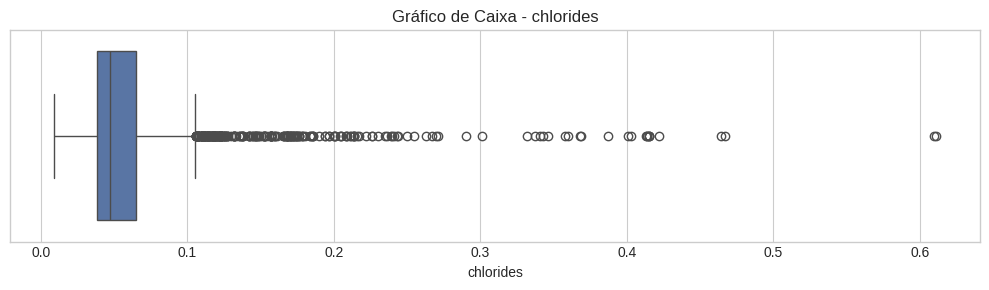

Comentário sobre chlorides:
- O boxplot de 'chlorides' evidencia a mediana, o intervalo interquartil e os valores extremos.
- Pontos fora dos limites da caixa indicam possíveis outliers.
- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.



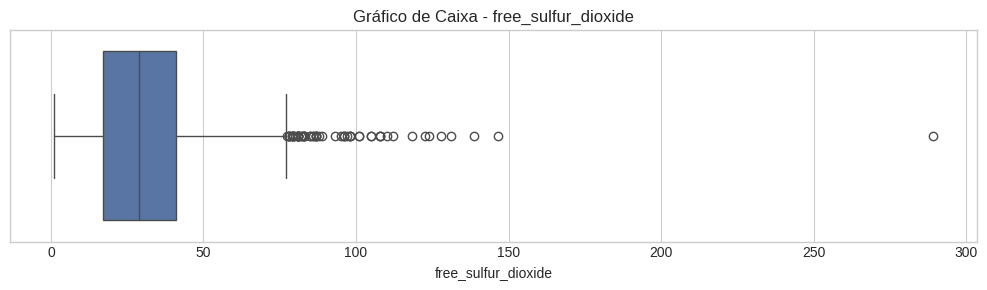

Comentário sobre free_sulfur_dioxide:
- O boxplot de 'free_sulfur_dioxide' evidencia a mediana, o intervalo interquartil e os valores extremos.
- Pontos fora dos limites da caixa indicam possíveis outliers.
- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.



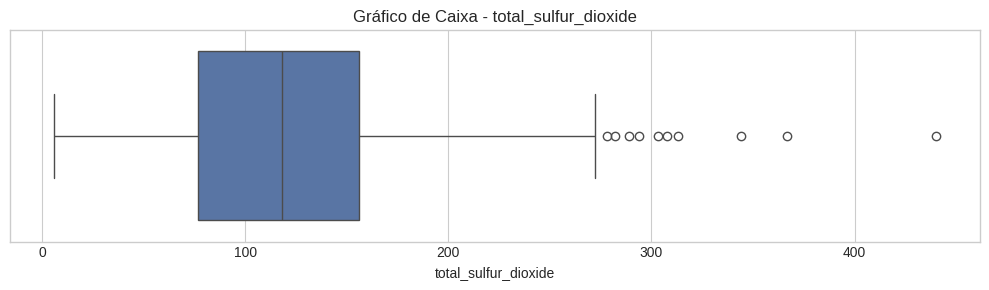

Comentário sobre total_sulfur_dioxide:
- O boxplot de 'total_sulfur_dioxide' evidencia a mediana, o intervalo interquartil e os valores extremos.
- Pontos fora dos limites da caixa indicam possíveis outliers.
- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.



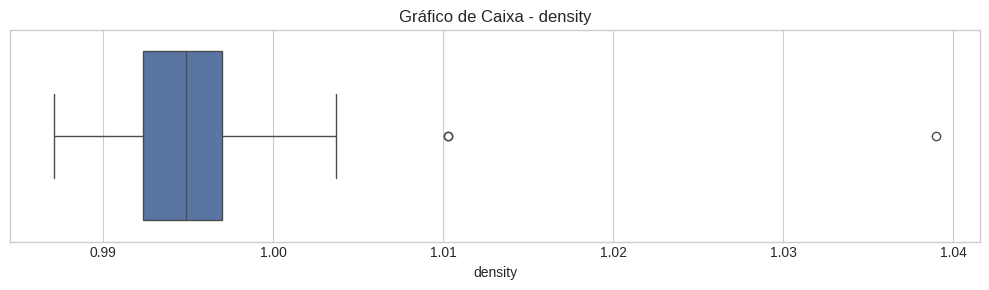

Comentário sobre density:
- O boxplot de 'density' evidencia a mediana, o intervalo interquartil e os valores extremos.
- Pontos fora dos limites da caixa indicam possíveis outliers.
- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.



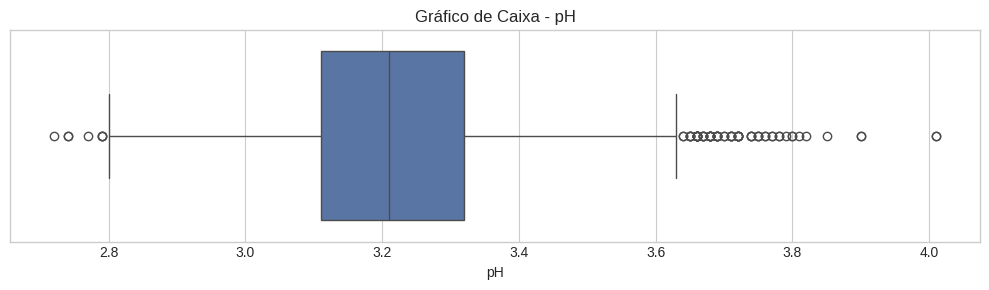

Comentário sobre pH:
- O boxplot de 'pH' evidencia a mediana, o intervalo interquartil e os valores extremos.
- Pontos fora dos limites da caixa indicam possíveis outliers.
- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.



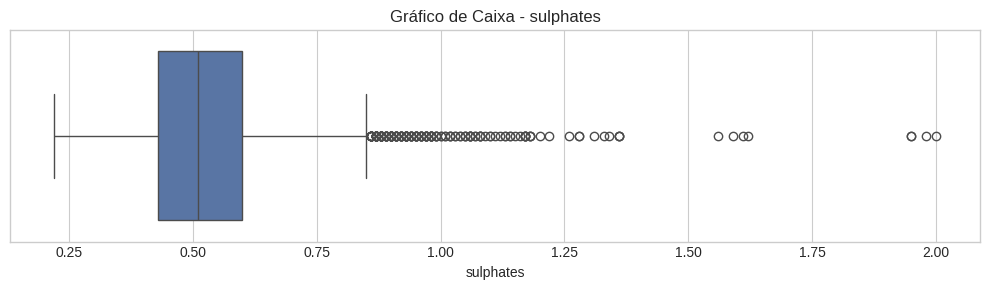

Comentário sobre sulphates:
- O boxplot de 'sulphates' evidencia a mediana, o intervalo interquartil e os valores extremos.
- Pontos fora dos limites da caixa indicam possíveis outliers.
- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.



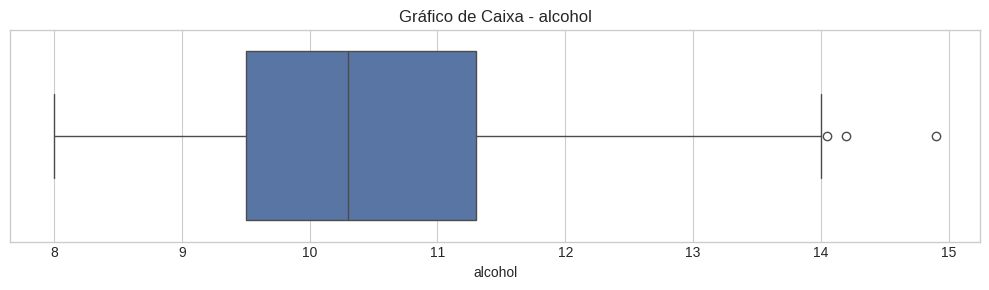

Comentário sobre alcohol:
- O boxplot de 'alcohol' evidencia a mediana, o intervalo interquartil e os valores extremos.
- Pontos fora dos limites da caixa indicam possíveis outliers.
- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.



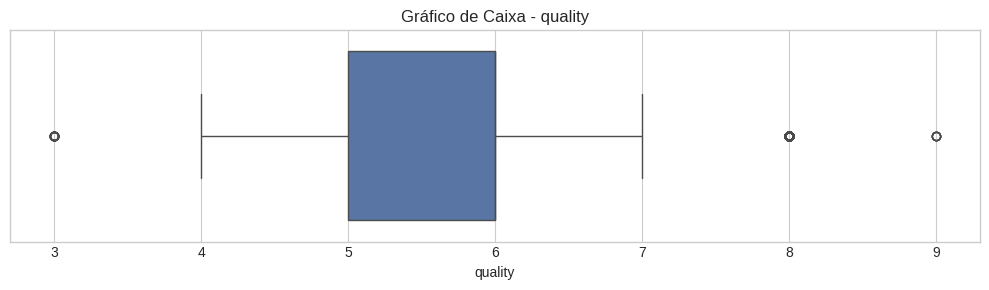

Comentário sobre quality:
- O boxplot de 'quality' evidencia a mediana, o intervalo interquartil e os valores extremos.
- Pontos fora dos limites da caixa indicam possíveis outliers.
- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.



In [18]:
for var in variaveis:
    plt.figure(figsize=(10, 3))

    sns.boxplot(x=df[var])
    plt.title(f"Gráfico de Caixa - {var}")
    plt.xlabel(var)
    plt.tight_layout()
    plt.show()

    print(f"Comentário sobre {var}:")
    print(
        f"- O boxplot de '{var}' evidencia a mediana, o intervalo interquartil e os valores extremos.\n"
        f"- Pontos fora dos limites da caixa indicam possíveis outliers.\n"
        f"- Uma caixa muito alongada indica maior dispersão; uma caixa curta indica maior concentração.\n"
    )

# Gráfico de Pizza

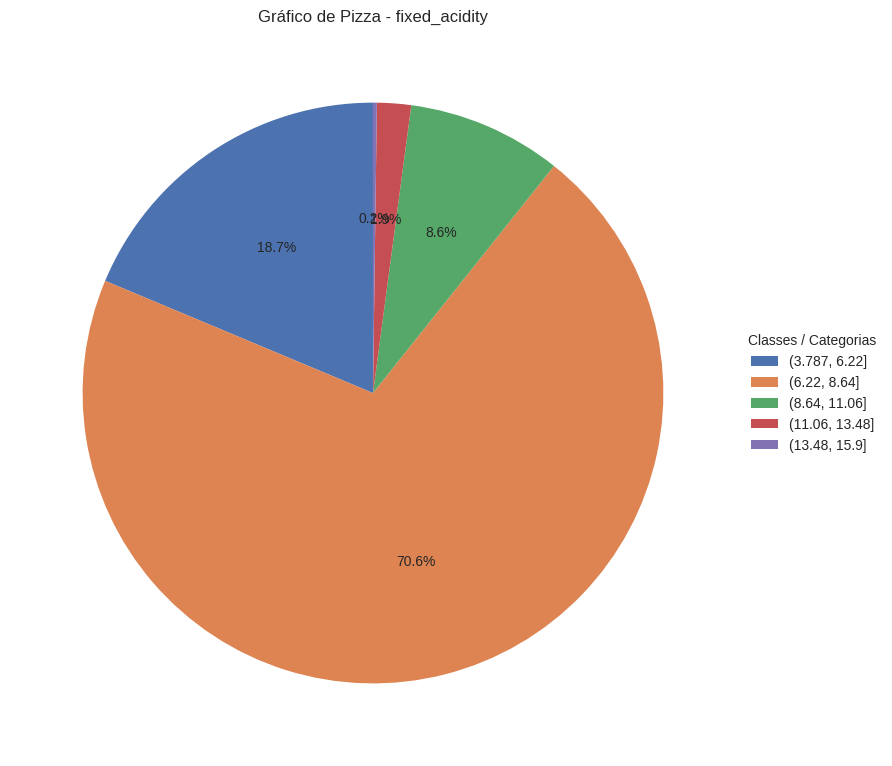

Comentário sobre fixed_acidity:
- O gráfico de pizza de 'fixed_acidity' mostra a proporção relativa das classes ou categorias.
- A legenda identifica claramente o significado de cada fatia.
- Para variáveis contínuas, os valores foram agrupados em faixas; para variáveis discretas ou categóricas, foram usadas as categorias originais.



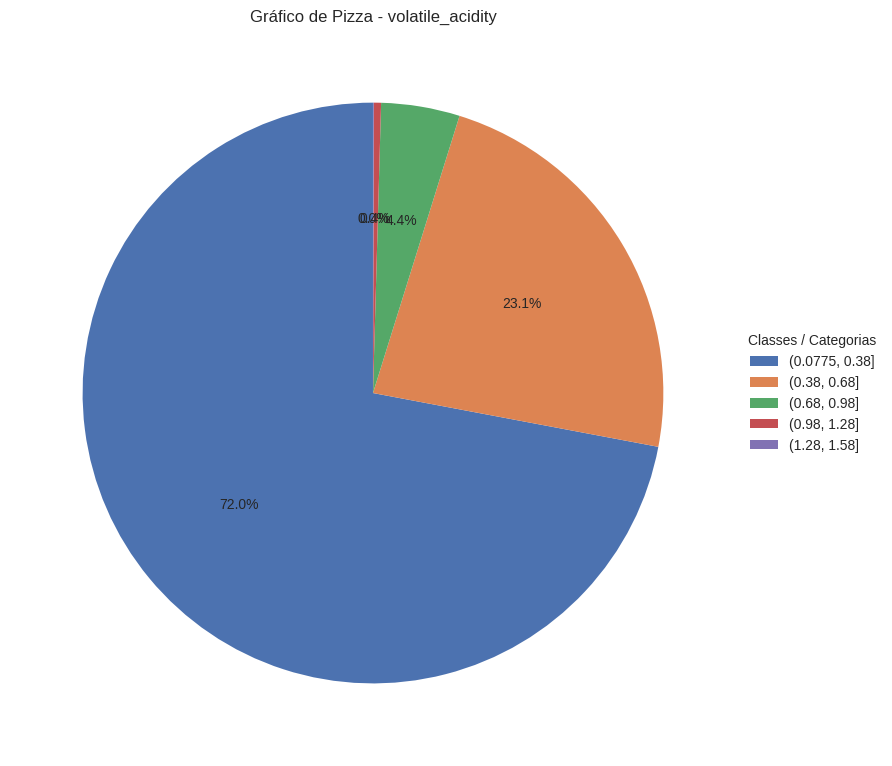

Comentário sobre volatile_acidity:
- O gráfico de pizza de 'volatile_acidity' mostra a proporção relativa das classes ou categorias.
- A legenda identifica claramente o significado de cada fatia.
- Para variáveis contínuas, os valores foram agrupados em faixas; para variáveis discretas ou categóricas, foram usadas as categorias originais.



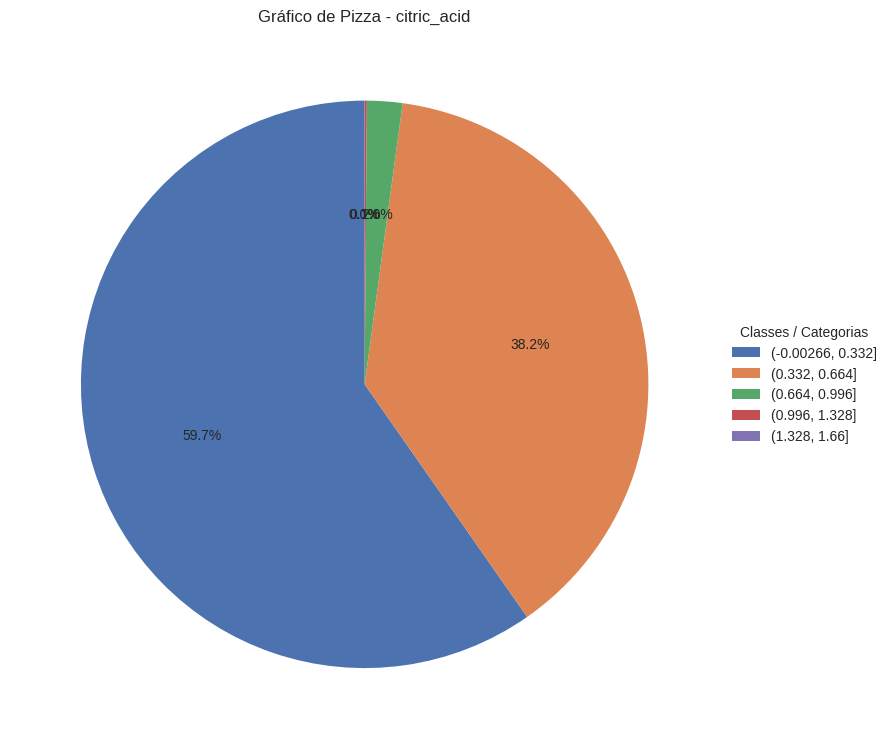

Comentário sobre citric_acid:
- O gráfico de pizza de 'citric_acid' mostra a proporção relativa das classes ou categorias.
- A legenda identifica claramente o significado de cada fatia.
- Para variáveis contínuas, os valores foram agrupados em faixas; para variáveis discretas ou categóricas, foram usadas as categorias originais.



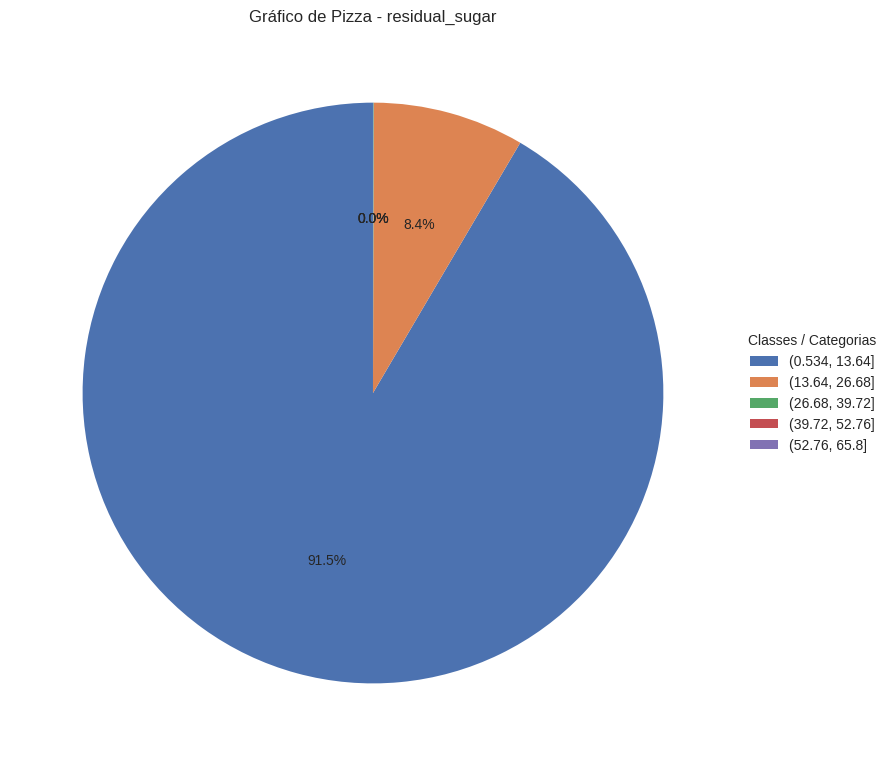

Comentário sobre residual_sugar:
- O gráfico de pizza de 'residual_sugar' mostra a proporção relativa das classes ou categorias.
- A legenda identifica claramente o significado de cada fatia.
- Para variáveis contínuas, os valores foram agrupados em faixas; para variáveis discretas ou categóricas, foram usadas as categorias originais.



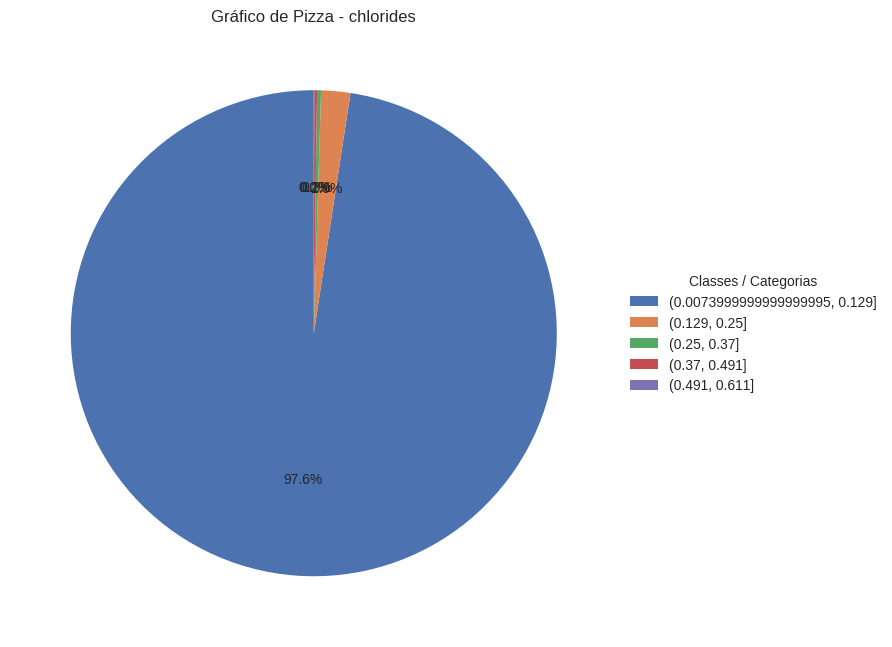

Comentário sobre chlorides:
- O gráfico de pizza de 'chlorides' mostra a proporção relativa das classes ou categorias.
- A legenda identifica claramente o significado de cada fatia.
- Para variáveis contínuas, os valores foram agrupados em faixas; para variáveis discretas ou categóricas, foram usadas as categorias originais.



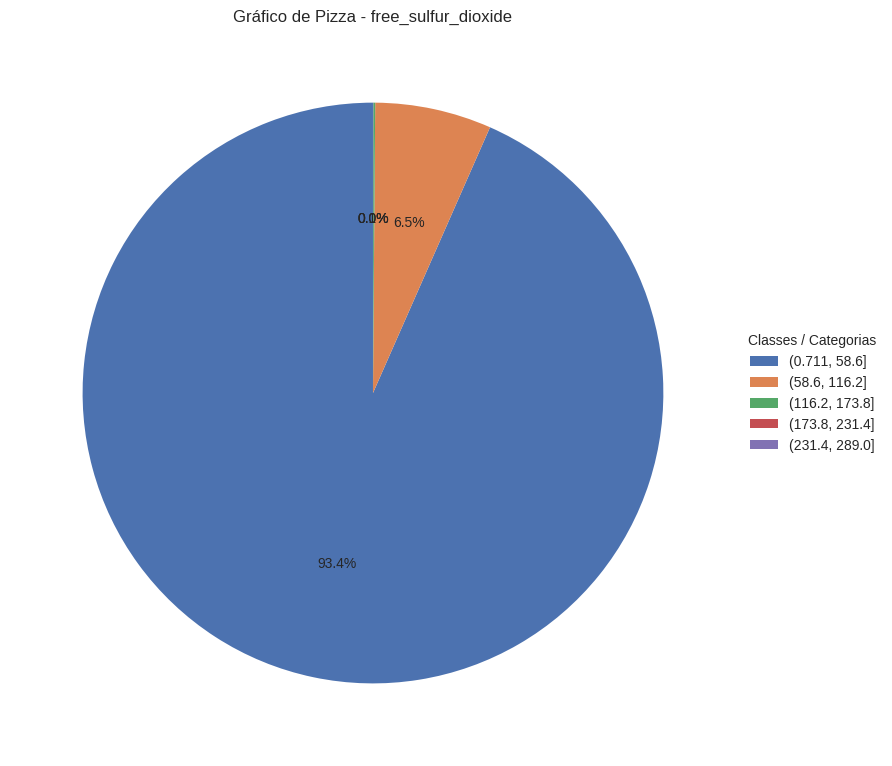

Comentário sobre free_sulfur_dioxide:
- O gráfico de pizza de 'free_sulfur_dioxide' mostra a proporção relativa das classes ou categorias.
- A legenda identifica claramente o significado de cada fatia.
- Para variáveis contínuas, os valores foram agrupados em faixas; para variáveis discretas ou categóricas, foram usadas as categorias originais.



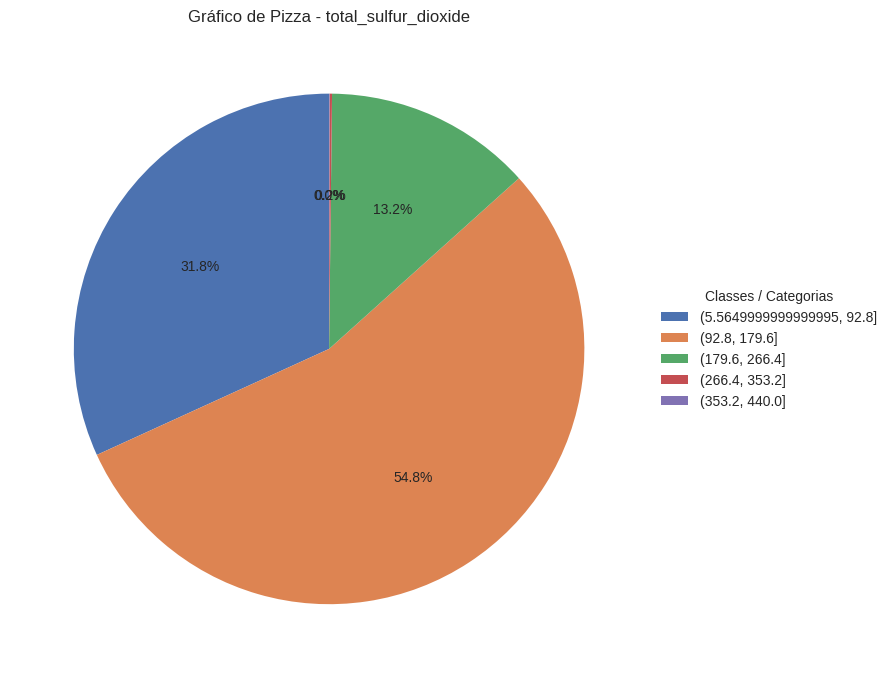

Comentário sobre total_sulfur_dioxide:
- O gráfico de pizza de 'total_sulfur_dioxide' mostra a proporção relativa das classes ou categorias.
- A legenda identifica claramente o significado de cada fatia.
- Para variáveis contínuas, os valores foram agrupados em faixas; para variáveis discretas ou categóricas, foram usadas as categorias originais.



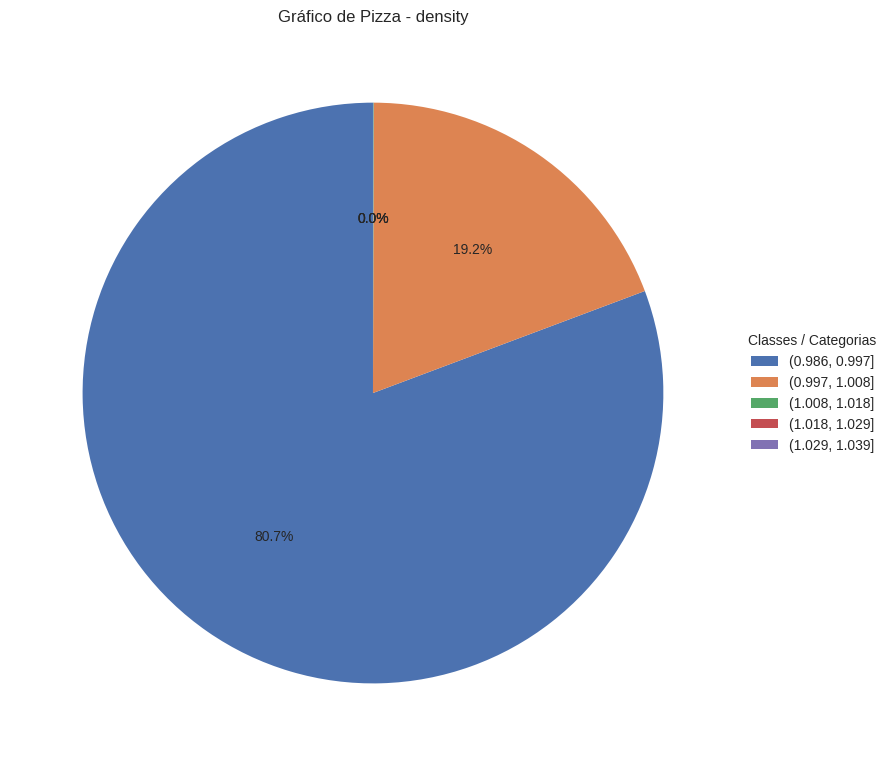

Comentário sobre density:
- O gráfico de pizza de 'density' mostra a proporção relativa das classes ou categorias.
- A legenda identifica claramente o significado de cada fatia.
- Para variáveis contínuas, os valores foram agrupados em faixas; para variáveis discretas ou categóricas, foram usadas as categorias originais.



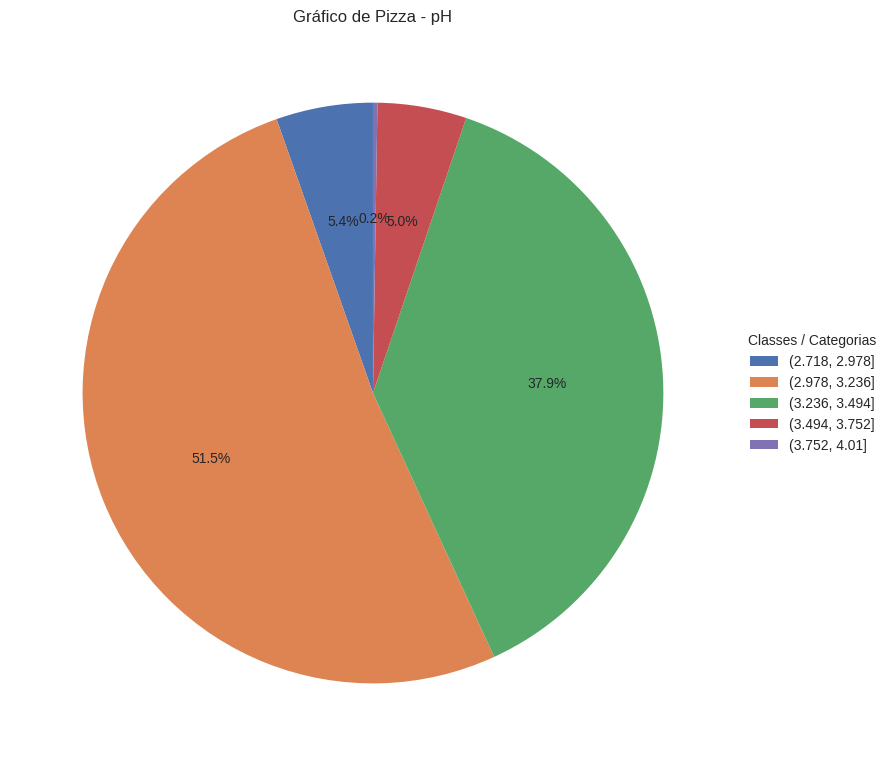

Comentário sobre pH:
- O gráfico de pizza de 'pH' mostra a proporção relativa das classes ou categorias.
- A legenda identifica claramente o significado de cada fatia.
- Para variáveis contínuas, os valores foram agrupados em faixas; para variáveis discretas ou categóricas, foram usadas as categorias originais.



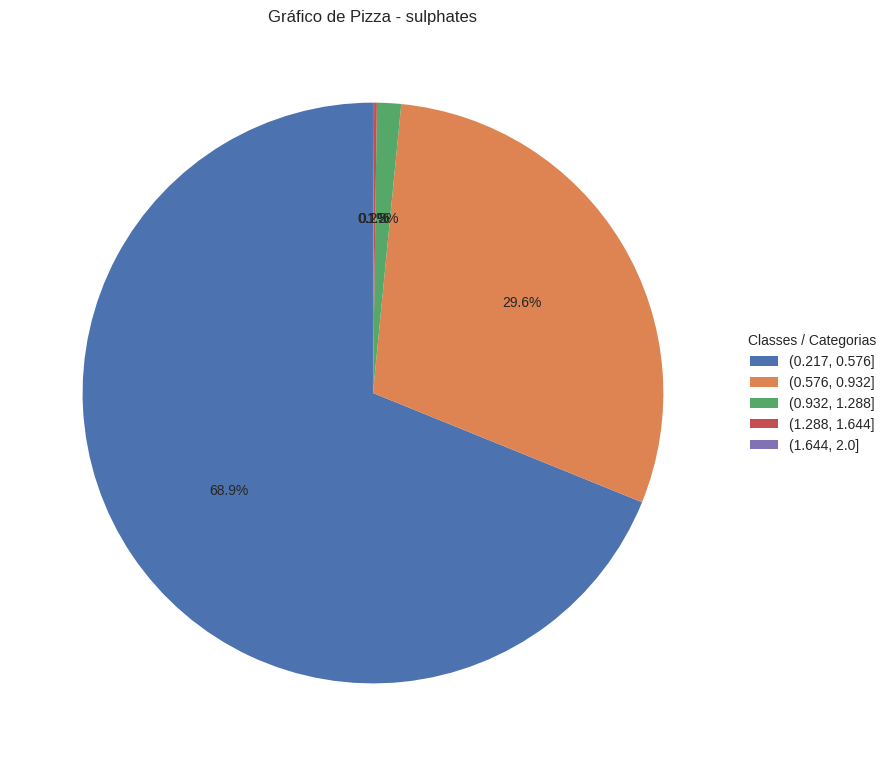

Comentário sobre sulphates:
- O gráfico de pizza de 'sulphates' mostra a proporção relativa das classes ou categorias.
- A legenda identifica claramente o significado de cada fatia.
- Para variáveis contínuas, os valores foram agrupados em faixas; para variáveis discretas ou categóricas, foram usadas as categorias originais.



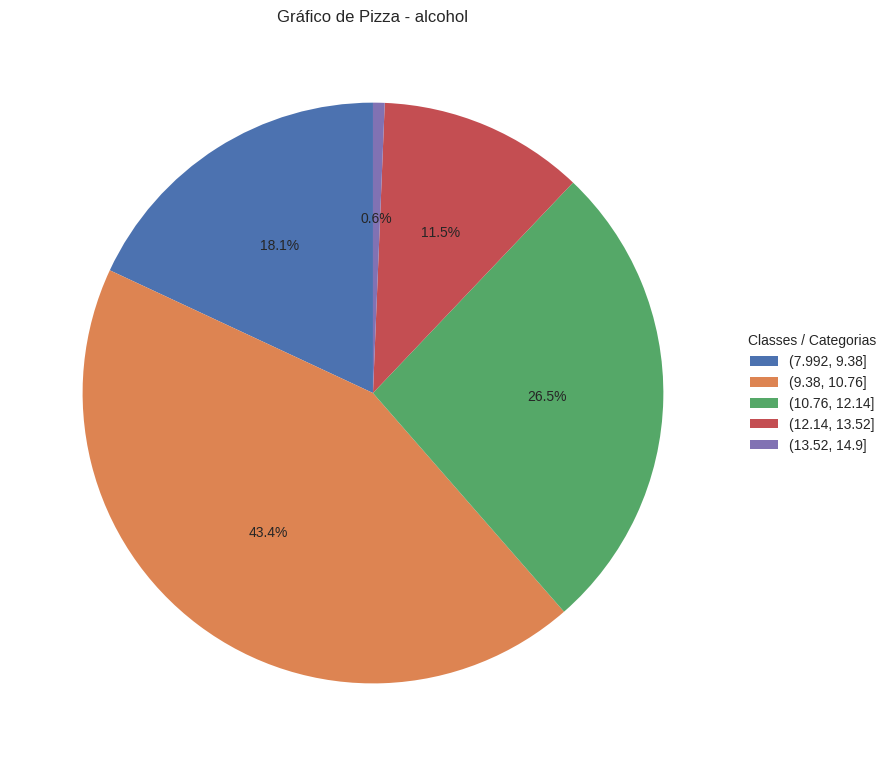

Comentário sobre alcohol:
- O gráfico de pizza de 'alcohol' mostra a proporção relativa das classes ou categorias.
- A legenda identifica claramente o significado de cada fatia.
- Para variáveis contínuas, os valores foram agrupados em faixas; para variáveis discretas ou categóricas, foram usadas as categorias originais.



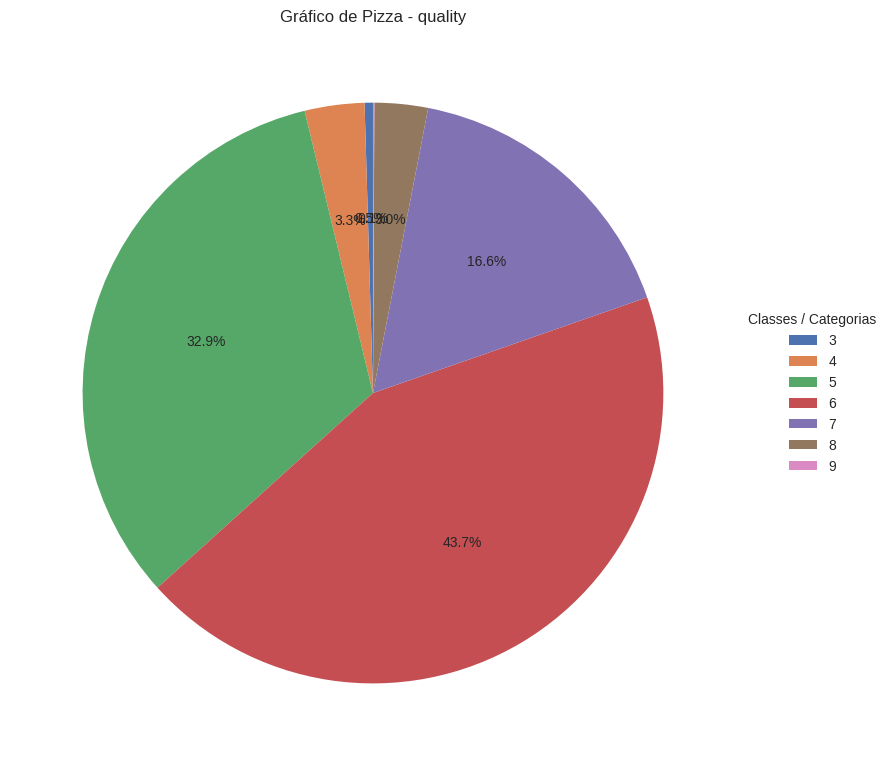

Comentário sobre quality:
- O gráfico de pizza de 'quality' mostra a proporção relativa das classes ou categorias.
- A legenda identifica claramente o significado de cada fatia.
- Para variáveis contínuas, os valores foram agrupados em faixas; para variáveis discretas ou categóricas, foram usadas as categorias originais.



In [19]:
from pandas.api.types import is_numeric_dtype
import pandas as pd


def frequencias_para_grafico(serie, nome_variavel=None, bins=6):
    """
    Retorna uma série de frequências adequada para gráficos.

    Regras:
    - Se for numérica e tiver poucos valores únicos (ex.: quality), usa valores originais
    - Se for numérica contínua, agrupa em classes
    - Se for categórica, usa categorias originais
    """
    serie = serie.dropna()

    if serie.empty:
        return pd.Series(dtype="int64")

    if is_numeric_dtype(serie):
        if nome_variavel == "quality" or serie.nunique() <= 10:
            freq = serie.value_counts().sort_index()
        else:
            classes = pd.cut(serie, bins=bins, include_lowest=True)
            freq = classes.value_counts().sort_index()
    else:
        freq = serie.astype(str).value_counts().sort_index()

    return freq


def labels_legiveis(freq_index):
    """
    Converte os rótulos do índice em texto legível para legenda.
    """
    return [str(x) for x in freq_index]




variaveis = df.columns.tolist()

for var in variaveis:
    freq = frequencias_para_grafico(df[var], nome_variavel=var, bins=5)

    if freq.empty:
        print(f"{var}: sem dados válidos para gerar gráfico de pizza.\n")
        continue

    labels = labels_legiveis(freq.index)

    plt.figure(figsize=(9, 9))

    wedges, texts, autotexts = plt.pie(
        freq.values,
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title(f"Gráfico de Pizza - {var}")

    plt.legend(
        wedges,
        labels,
        title="Classes / Categorias",
        loc="center left",
        bbox_to_anchor=(1.0, 0.5)
    )

    plt.tight_layout()
    plt.show()

    print(f"Comentário sobre {var}:")
    print(
        f"- O gráfico de pizza de '{var}' mostra a proporção relativa das classes ou categorias.\n"
        f"- A legenda identifica claramente o significado de cada fatia.\n"
        f"- Para variáveis contínuas, os valores foram agrupados em faixas; "
        f"para variáveis discretas ou categóricas, foram usadas as categorias originais.\n"
    )

# Pizza - Notas de Qualidade

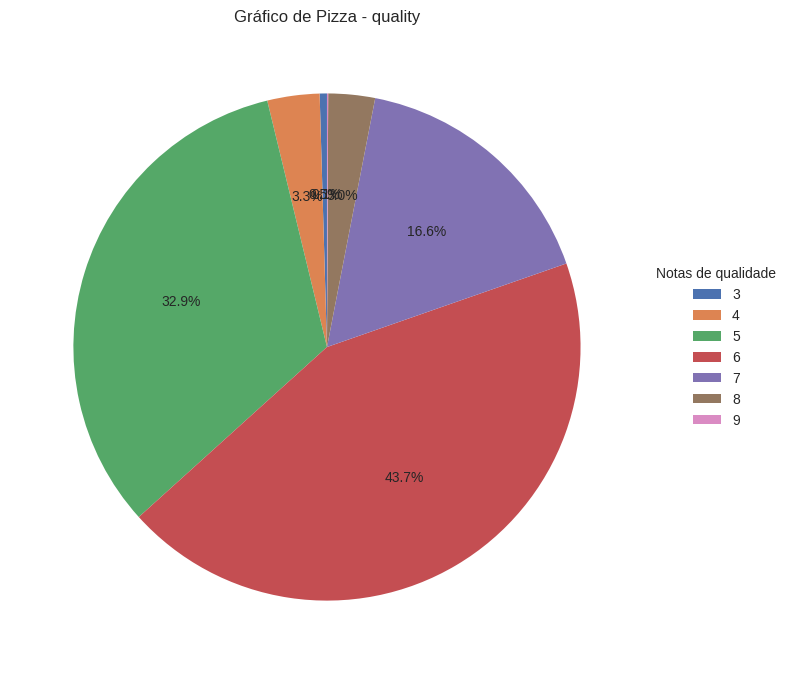

In [20]:
var = "quality"

freq = frequencias_para_grafico(df[var], nome_variavel=var, bins=5)
labels = labels_legiveis(freq.index)

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    freq.values,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(f"Gráfico de Pizza - {var}")
plt.legend(
    wedges,
    labels,
    title="Notas de qualidade",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)
plt.tight_layout()
plt.show()